Домашнее задание.

ДЗ №6 «Анализ новостей»

Цель:

Студенты учатся использовать сложные предобученные модели для улучшения модели.
Цель - Собрать модель с LLM для оценки тональности новостей.


Описание/Пошаговая инструкция выполнения домашнего задания:

- Добавить в модель анализ тональности новостей и их влияние на позиции из портфеля;
- Выполнить оценку качества модели.

Загружаем используемые библиотеки

In [ ]:
!pip3 install finnhub-python
!pip3 install -U sentence-transformers torch
#!pip3 install backtesting
#!pip3 install bokeh==3.8.1
!pip3 install intel_extension_for_pytorch
!pip install pandas-ta

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.3/39.3 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.0/90.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.

In [ ]:
from transformers import T5Tokenizer, T5ForConditionalGeneration

In [ ]:
from sentence_transformers import SentenceTransformer

import finnhub
import pandas as pd
from datetime import datetime, timedelta
import time

import numpy as np
import re
import os

import yfinance as yf
from datetime import datetime

import torch.nn as nn
import torch.optim as optim
import torch
from torch.utils.data import TensorDataset, DataLoader



In [ ]:

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
import matplotlib.pyplot as plt
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
import joblib
from scipy.fft import fft
from IPython.display import display
import pywt
from scipy.stats import skew, kurtosis
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

Finbert для CPU (очень медленно)

In [ ]:
# Finbert для CPU
import torch
from transformers import AutoTokenizer, AutoModel
import pandas as pd

device = "cpu"
model_name = "ProsusAI/finbert"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model_finbert = AutoModel.from_pretrained(model_name).to(device)

# --- ОПТИМИЗАЦИЯ ДЛЯ CPU В PYTORCH 2.9 ---

# 1. Динамическое квантование (самый мощный прирост на CPU)
# Оно не требует IPEX и отлично работает в PyTorch 2.9
model_finbert = torch.ao.quantization.quantize_dynamic(
    model_finbert, {torch.nn.Linear}, dtype=torch.qint8
)

# 2. Компиляция под CPU (Inductor backend)
# В PyTorch 2.9 это заменяет многие функции IPEX
model_finbert = torch.compile(model_finbert, backend="inductor")

model_finbert.eval()

# 1. Динамическое квантование (уменьшает веса с float32 до int8)
# Это дает 2-3 кратное ускорение на CPU без значительной потери точности
#model_finbert = torch.quantization.quantize_dynamic(
#    model_finbert, {torch.nn.Linear}, dtype=torch.qint8
#)

# 2. Оптимизация IPEX
# model_finbert = ipex.optimize(model_finbert, dtype=torch.float32)
# Примечание: Квантованную модель ipex.optimize обрабатывает автоматически

def finbert_embedding_cpu(sentences, batch_size=16): # Уменьшаем батч для CPU
    if isinstance(sentences, pd.Series):
        sentences = sentences.tolist()

    all_vectors = []

    for i in range(0, len(sentences), batch_size):
        batch = sentences[i : i + batch_size]

        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            # На CPU не используем .half(), так как мы применили квантование
            outputs = model_finbert(**inputs)

            # Mean Pooling
            attention_mask = inputs['attention_mask']
            token_embeddings = outputs.last_hidden_state
            input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()

            sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)
            sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
            batch_embeddings = sum_embeddings / sum_mask
            batch_embeddings = torch.nn.functional.normalize(batch_embeddings, p=2, dim=1)

            all_vectors.extend(batch_embeddings.numpy().tolist())

    return pd.Series(all_vectors)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

/tmp/ipython-input-1842471941.py:16: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_finbert = torch.ao.quantization.quantize_dynamic(


Finbert для CUDA

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModel
import pandas as pd

device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "ProsusAI/finbert"

# Загрузка токенизатора и модели
tokenizer = AutoTokenizer.from_pretrained(model_name)
model_finbert = AutoModel.from_pretrained(model_name).to(device)

# ОПТИМИЗАЦИЯ 2026: Перевод в полуточность и компиляция (Triton Backend)
model_finbert = model_finbert.half() # Экономия 50% VRAM
model_finbert = torch.compile(model_finbert) # Ускорение инференса через Triton
model_finbert.eval()

def finbert_embedding_text(sentences, batch_size=32):
    if isinstance(sentences, pd.Series):
        sentences = sentences.tolist()

    all_vectors = []

    # Обработка батчами
    for i in range(0, len(sentences), batch_size):
        batch = sentences[i : i + batch_size]

        # Токенизация с динамическим паддингом (быстрее, чем фиксированный)
        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128, # Для новостей 128 обычно достаточно
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            # Инференс
            outputs = model_finbert(**inputs)

            # MEAN POOLING: Усреднение скрытых состояний для получения одного вектора
            # Это стандарт для получения качественного эмбеддинга из BERT
            attention_mask = inputs['attention_mask']
            token_embeddings = outputs.last_hidden_state
            input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()

            sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)
            sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
            batch_embeddings = sum_embeddings / sum_mask

            # Нормализация (как в BGE)
            batch_embeddings = torch.nn.functional.normalize(batch_embeddings, p=2, dim=1)

            # Перенос на CPU и очистка памяти
            all_vectors.extend(batch_embeddings.cpu().to(torch.float32).numpy().tolist())

            # Явная очистка текущих тензоров батча
            del outputs, inputs, batch_embeddings

    print(f"Обработано векторов: {len(all_vectors)}")
    print(f"Размерность вектора FinBERT: {len(all_vectors[0])}") # Будет 768

    return pd.Series(all_vectors)

DistilBART - сочетает мощь CNN-обучения и скорость base-моделей - не использовал

In [ ]:
import torch
import pandas as pd
from transformers import BartTokenizer, BartForConditionalGeneration
import numpy as np

# --- 1. Настройка устройства ---
device = "cpu"

# Используем DistilBART - она сочетает мощь CNN-обучения и скорость base-моделей
model_name_BART = 'sshleifer/distilbart-cnn-12-6'
tokenizer = BartTokenizer.from_pretrained(model_name_BART)
model = BartForConditionalGeneration.from_pretrained(model_name_BART)

# --- 2. Динамическое квантование для CPU ---
# Ускоряет инференс в 2-3 раза за счет перевода весов в int8
model = torch.quantization.quantize_dynamic(
    model, {torch.nn.Linear}, dtype=torch.qint8
)

model.eval()

def bart_summarize_text_cpu(text):
    if isinstance(text, pd.Series):
        texts = text.fillna("").astype(str).to_list()
    else:
        texts = [str(text)]

    # Токенизация
    inputs = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        max_length=512, # 512 обычно достаточно для финансовых новостей
        truncation=True
    ).to(device)

    with torch.no_grad():
        # Параметры генерации для DistilBART
        summary_ids = model.generate(
            **inputs,
            max_new_tokens=70,
            min_length=15,
            num_beams=2,         # Оптимально для баланса скорость/качество на CPU
            length_penalty=2.0,  # Возвращаем стандартный штраф для суммаризации
            no_repeat_ngram_size=3,
            early_stopping=True,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    summary = tokenizer.batch_decode(summary_ids, skip_special_tokens=True)
    return pd.DataFrame(summary, columns=['summary'])

# --- 3. Тест ---
financial_report = """
NVIDIA (NVDA) reports record-breaking revenue for 2024, driven by massive demand for AI chips.
The company's stock surged 15% in pre-market trading as analysts raise price targets.
CEO Jensen Huang stated that the generative AI era is just beginning.
"""
summary_df = bart_summarize_text_cpu(financial_report)
print("Результат суммаризации:")
print(summary_df['summary'].iloc[0])


ValueError: Name tf.RaggedTensorSpec has already been registered for class tensorflow.python.ops.ragged.ragged_tensor.RaggedTensorSpec.

bart-large-cnn - использовалась для суммаризации записей (2022 - 2025 kaggle - 38тыс новостей, 2025 - 2026 finnhub - 11тыс новостей)

In [ ]:
import torch
from transformers import BartTokenizer, BartForConditionalGeneration # Изменяем импорт
import pandas as pd

device_map = "cuda" if torch.cuda.is_available() else "cpu"

# --- ИЗМЕНЕНИЕ 1: Загрузка модели BART вместо T5 ---
model_name_BART = 'facebook/bart-large-cnn'
tokenizer = BartTokenizer.from_pretrained(model_name_BART)
model_T5 = BartForConditionalGeneration.from_pretrained(model_name_BART) # Используем ту же переменную model_T5 для минимизации изменений ниже

# --- ОПТИМИЗАЦИЯ ДЛЯ COLAB/GPU ---
model_T5 = model_T5.to(device_map)
model_T5 = model_T5.half() # Переводим в FP16 для экономии VRAM
model_T5 = torch.compile(model_T5) # Опционально: ускорение через Triton compile
model_T5.eval()

# Пример текста финансового отчета (оставляем как есть)
financial_report = """
Tesla has posted strong earnings in the first quarter of 2024, reporting a revenue of $25 billion,
up 15% compared to the same period last year. The company announced that its Model Y sales grew by
20%, contributing to the overall revenue surge. Despite the positive results, Tesla faces challenges
in scaling up its production of batteries, which could affect future growth prospects. Tesla’s stock price
rose by 10% in the aftermath of the earnings report, reflecting investor optimism. Analysts are closely
monitoring the company’s expansion in Europe and its plans to build new factories in Asia.
"""

# Функция для суммирования
def bart_summarize_text(text):
    if isinstance(text, pd.Series):
        texts = text.to_list()
    else:
        # Если передан одиночный текст (как в примере financial_report)
        texts = [text]

    # --- ИЗМЕНЕНИЕ 2: Для BART не требуется префикс "summarize: " ---
    # texts = ["summarize: " + str(t) for t in texts] # Комментируем эту строку

    inputs = tokenizer(texts, return_tensors="pt", padding=True, max_length=1024, truncation=True).to(device_map)

    # Переводим входные данные в float16 (уже сделано при загрузке модели, но здесь перестраховка)
    if model_T5.dtype == torch.float16:
        inputs = {k: v.half() if v.dtype == torch.float32 else v for k, v in inputs.items()}

    # Генерация краткого текста
    with torch.no_grad():
      summary_ids = model_T5.generate(
              **inputs,
              max_new_tokens=150,
              min_length=10,
              length_penalty=2.0,
              num_beams=4, # Для BART-Large 4 луча дают лучшее качество, чем 2
              early_stopping=True,
              pad_token_id=tokenizer.pad_token_id,
              eos_token_id=tokenizer.eos_token_id,
              decoder_start_token_id=model_T5.config.decoder_start_token_id,
              forced_eos_token_id=tokenizer.eos_token_id
          )

    # Декодирование результата
    summary = tokenizer.batch_decode(summary_ids, skip_special_tokens=True, clean_up_tokenization_spaces=True)

    # Очистка тензоров из памяти GPU
    del inputs
    del summary_ids
    torch.cuda.empty_cache() # Дополнительная очистка VRAM

    return pd.DataFrame(summary, columns=['summary'])

# Пример использования с одиночным текстом
summary_df = bart_summarize_text(financial_report)
print(summary_df.iloc[0]['summary'])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

Tesla has posted strong earnings in the first quarter of 2024, reporting a revenue of $25 billion. The company announced that its Model Y sales grew by 20%. Despite the positive results, Tesla faces challengesin scaling up its production of batteries.


Обработка новостей с kaggle

In [ ]:
from google.colab import drive, files

import gc
import os
import csv
# 1. Set this BEFORE importing torch
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
import torch
from pathlib import Path

drive.mount('/content/drive', force_remount=True)

file_path_kaggle = '/content/drive/MyDrive/Finance/NVDA_news_2022_2025_sub.csv'
file_path_new_kaggle = '/content/drive/MyDrive/Finance/NVDA_kaggle.csv'
try:
    df_kaggle = pd.read_csv(file_path_kaggle,
                            parse_dates=['time_published'], # Автоматически делает datetime64[ns]
                            on_bad_lines='skip',
                            encoding='utf-8-sig')
    print(df_kaggle.head())
    print(f"MIN: {df_kaggle['time_published'].min()}")
    print(f"MAX: {df_kaggle['time_published'].max()}")
    print(f"Count: {len(df_kaggle)}")
    print(f"Файл {file_path_kaggle} успешно загружен!")
except Exception as e:
    print(f"Ошибка при загрузке {file_path_kaggle} : {e}")

df_kaggle['time_published'] = pd.to_datetime(df_kaggle['time_published'], unit='s', errors='coerce')
df_kaggle = df_kaggle.sort_values(by='time_published', ascending=False)
print(f"Post MIN: {df_kaggle['time_published'].min()}")
print(f"Post MAX: {df_kaggle['time_published'].max()}")
print(f"Count: {len(df_kaggle)}")
df_kaggle = df_kaggle[['time_published', 'Summary']]
df_kaggle = df_kaggle.rename(columns={'time_published': 'Date'})

df_kaggle['Summary'] = df_kaggle['Summary'].str[:512].apply(lambda x: f'"""{x}"""')
df_kaggle['Summary'] = df_kaggle['Summary'].str.replace(r'\u200b', '', regex=True).str.replace(r'[\x00-\x1F\x7F-\x9F]', '', regex=True).str.strip()
df_kaggle = df_kaggle.dropna()

print(df_kaggle.head())
print(f"Pred save MIN: {df_kaggle['Date'].min()}")
print(f"Pred save MAX: {df_kaggle['Date'].max()}")
print(f"Count: {len(df_kaggle)}")

df_kaggle.to_csv(file_path_new_kaggle, index=False, encoding='utf-8-sig')
print(f"Данные news успешно сохранены в: {file_path_new_kaggle}")
#
# MIN: 2022-03-03 21:03:36
# MAX: 2025-04-05 19:31:48
# Count: 38820
#



Mounted at /content/drive
                                             Summary      time_published
0  [Sponsored Article]\r\rThe Covid-19 pandemic h... 2022-03-03 21:03:36
1  A lot of money continues to flow into hedge fu... 2022-03-04 17:22:00
2  There are plenty of ways to invest in blockcha... 2022-03-04 19:36:00
3  The chip giant was recently the victim of a hack. 2022-03-06 00:00:00
4  Multinational companies grapple with a fractur... 2022-03-07 11:13:11
MIN: 2022-03-03 21:03:36
MAX: 2025-04-05 19:31:48
Count: 38820
Файл /content/drive/MyDrive/Finance/NVDA_news_2022_2025_sub.csv успешно загружен!
Post MIN: 2022-03-03 21:03:36
Post MAX: 2025-04-05 19:31:48
Count: 38820
                     Date                                            Summary
38819 2025-04-05 19:31:48  """Elon Musk's fortune takes a $12 billion hit...
38818 2025-04-05 14:32:00  """The tech sell-off of 2025 has created sever...
38817 2025-04-05 14:04:00  """Investing in the best growth stocks in the ...
38816 2025

Суммаризация новостей с kaggle и finnhub c помощью bart-large-cnn

In [ ]:

from google.colab import drive, files

import gc
import os
import csv
# 1. Set this BEFORE importing torch
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
import torch
from pathlib import Path

drive.mount('/content/drive', force_remount=True)
#files.download('temp_data.csv')
file_path = '/content/drive/MyDrive/Finance/my_news_data.csv'

file_path_sentences = '/content/drive/MyDrive/Finance/my_sentences.csv'
file_path_new_kaggle = '/content/drive/MyDrive/Finance/NVDA_kaggle.csv'
file_path_summ_news = '/content/drive/MyDrive/Finance/NVDA_summ_news_20220303_20260111.csv'

# Инициализация клиента Finnhub (замените на ваш ключ)
# finnhub_client = finnhub.Client(api_key="ВАШ_API_КЛЮЧ")
finnhub_client = finnhub.Client(api_key="xxx")


def fetch_news_weekly_chunks(ticker, days_back=365, start_date_full=datetime.strptime('2025-01-17', '%Y-%m-%d'), end_date_full=datetime.strptime('2026-01-11','%Y-%m-%d')):
    all_news = []

    # Определяем общий диапазон
    #end_date_full = datetime.now()
    #start_date_full = end_date_full - timedelta(days=days_back)

    current_start = start_date_full

    print(f"Начало сбора данных за {days_back} дней, разбивая на недельные чанки...")

    # Цикл с шагом в 7 дней
    while current_start < end_date_full:
        current_end = current_start + timedelta(days=7)

        # Если конечная дата выходит за общий диапазон, ограничиваем ее
        if current_end > end_date_full:
            current_end = end_date_full

        # Форматируем даты для API Finnhub (YYYY-MM-DD)
        from_str = current_start.strftime('%Y-%m-%d')
        to_str = current_end.strftime('%Y-%m-%d')

        #print(f"  Запрос интервала: {from_str} to {to_str}")

        try:
            # Запрос к API
            news_batch = finnhub_client.company_news(ticker, _from=from_str, to=to_str)
            all_news.extend(news_batch)

            #print(f"    Получено новостей: {len(news_batch)}")

            # Пауза, чтобы не превысить лимит запросов в минуту (60/мин на free-tier)
            time.sleep(1)

        except Exception as e:
            print(f"    Ошибка при запросе интервала {from_str} - {to_str}: {e}")
            break

        # Сдвигаем начальную дату для следующей итерации
        current_start = current_end

    # Обработка результатов
    if not all_news:
        return pd.DataFrame()

    df = pd.DataFrame(all_news)
    df.drop_duplicates(subset='id', inplace=True) # Удаляем дубликаты, если есть пересечения
    df['datetime'] = pd.to_datetime(df['datetime'], unit='s', errors='coerce')
    df = df.sort_values(by='datetime', ascending=False)

    #return df[['datetime', 'headline', 'source', 'url', 'summary']]
    return df[['datetime', 'summary']]


print("="*70)
# Подготовка данных из Pandas
try:
    df_full_year = pd.read_csv(file_path)
    print("Файл успешно загружен!")
except Exception as e:
    print(f"Ошибка при загрузке news: {e}")

if df_full_year.empty:
     # Загрузка новостей NVDA за последний год (365 дней)
     # df_full_year = fetch_news_weekly_chunks('NVDA', days_back=365)
     if not df_full_year.empty:
        print(f"\nИтого уникальных новостей за год: {len(df_full_year)}")
    #   pd.set_option('display.max_colwidth', None)
        df_full_year['summary'] = df_full_year['summary'].str[:512].apply(lambda x: f'"""{x}"""')
        df_full_year['summary'] = df_full_year['summary'].str.replace(r'\u200b', '', regex=True).str.replace(r'[\x00-\x1F\x7F-\x9F]', '', regex=True).str.strip()
        # df_full_year.to_csv(file_path, index=False, encoding='utf-8-sig')
        print(f"Данные news успешно сохранены в: {file_path}")
    ##df_full_year_news = df_full_year['summary'].apply(lambda x: summarize_text(str(x)) if len(str(x).strip()) > 0 else "") - долго, не батч
    ##texts = ["summarize: " + str(t) for t in df_full_year['summary'].to_list()]
    ###df_full_year['summary'] = summarize_text(df_full_year['summary'])

df_kaggle_news = pd.read_csv(file_path_new_kaggle,
                         on_bad_lines='skip',
                         quoting=csv.QUOTE_MINIMAL,
                         encoding='utf-8-sig')
df_full_year = df_full_year.rename(columns={'datetime': 'Date'})
df_full_year = df_full_year.rename(columns={'summary': 'Summary'})
df_full_year = pd.concat([df_full_year, df_kaggle_news])
df_full_year['Date'] = pd.to_datetime(df_full_year['Date'], errors='coerce')
df_full_year = df_full_year.sort_values(by='Date', ascending=False)
df_full_year['Summary'] = df_full_year['Summary'].str[:512].apply(lambda x: f'"""{x}"""')
df_full_year['Summary'] = df_full_year['Summary'].str.replace(r'\u200b', '', regex=True).str.replace(r'[\x00-\x1F\x7F-\x9F]', '', regex=True).str.strip()
df_full_year['Summary'] = df_full_year['Summary'].str.replace(r"['\"\[\]]", "", regex=True).str.strip()

# 2. Заменяем пустые строки на NaN (чтобы их можно было легко удалить)
df_full_year['Summary'] = df_full_year['Summary'].replace('', np.nan)

# 3. Удаляем строки, где summary теперь пустое (NaN)
df_full_year = df_full_year.dropna(subset=['Summary'])
df_full_year = df_full_year.dropna()

df_full_year = df_full_year.rename(columns={'Summary': 'summary'})
print(df_full_year.head())
print(f"Pred save MIN: {df_full_year['Date'].min()}")
print(f"Pred save MAX: {df_full_year['Date'].max()}")
print(f"Count: {len(df_full_year)}")
df_full_year.to_csv(file_path_summ_news,
                    encoding='utf-8-sig',
                    quoting=csv.QUOTE_MINIMAL # Защита от запятых в тексте
                    )

# Удаляем старый файл, если он существует
output_file = Path(file_path_sentences)
if output_file.exists():
    output_file.unlink()


## Суммаризация новостей
try:
    reader = pd.read_csv(file_path_summ_news, chunksize=100)
    first_batch = True
    with torch.no_grad():
      for batch in reader:
            gc.collect()
            torch.cuda.empty_cache()
            if 'summary' not in batch.columns:
              raise KeyError(f"Колонка 'summary' не найдена. Доступные колонки: {list(batch.columns)}")
            input_texts = batch['summary'].fillna("").astype(str)
            summarized_results = bart_summarize_text(input_texts)
            torch.cuda.empty_cache()
            if isinstance(summarized_results, (pd.DataFrame, pd.Series)):
                batch['summary'] = summarized_results.iloc[:, 0].values if isinstance(summarized_results, pd.DataFrame) else summarized_results.values
            else:
                batch['summary'] = summarized_results
            #print(f"{file_path_sentences}")
            batch.to_csv(file_path_sentences,
                    mode='a',
                    index=False,
                    header=first_batch,
                    encoding='utf-8-sig',
                    quoting=csv.QUOTE_MINIMAL # Защита от запятых в тексте
                    )
            first_batch = False
            del summarized_results, batch
            gc.collect()
            torch.cuda.empty_cache()
    print(f"Суммаризация завершена. Файл с датами сохранен: {output_file}")

except Exception as e:
    print(f"Ошибка при загрузке summary news: {e}")

#Pred save MIN: 2020-06-12 21:14:04
#Pred save MAX: 2026-01-11 23:20:23
#Count: 49857
#Суммаризация завершена. Файл с датами сохранен: /content/drive/MyDrive/Finance/my_sentences.csv




Mounted at /content/drive
Файл успешно загружен!
                 Date                                            summary
0 2026-01-11 23:20:23  X is developing a feature that turns ticker sy...
1 2026-01-11 23:05:00  Nvidia stock has made fortunes for patient inv...
2 2026-01-11 22:50:00  SoundHound continues to post losses, but thats...
3 2026-01-11 22:10:10  PepsiCo, Inc. (NASDAQ:PEP) is included among t...
4 2026-01-11 22:05:00  Archer Aviation recently announced it is colla...
Pred save MIN: 2020-06-12 21:14:04
Pred save MAX: 2026-01-11 23:20:23
Count: 49857
Суммаризация завершена. Файл с датами сохранен: /content/drive/MyDrive/Finance/my_sentences.csv


Предобработка перед созданием embeddings с помощью finbert

In [ ]:
from google.colab import drive
import pandas as pd
import csv

drive.mount('/content/drive', force_remount=True)

file_path_sent_news_raw = '/content/drive/MyDrive/Finance/news_summ2022-2026.csv'
file_path_sentences = '/content/drive/MyDrive/Finance/my_sentences.csv'

df_news_summ = pd.read_csv(file_path_sentences,
                         on_bad_lines='skip',
                         quoting=csv.QUOTE_MINIMAL,
                         encoding='utf-8-sig')

df_news_summ = df_news_summ[['Date','summary']]
df_news_summ['Date'] = pd.to_datetime(df_news_summ['Date'], errors='coerce')
df_news_summ = df_news_summ.sort_values(by='Date', ascending=False)
df_news_summ = df_news_summ.dropna(subset=['Date']) # Удаляем строки с неверными датами

# --- Очистка текста от спецсимволов и кавычек ---
# Используем .str.replace для удаления невидимых, управляющих символов и всех кавычек
df_news_summ['summary'] = df_news_summ['summary'].str.replace(r'\u200b', '', regex=True) \
                                               .str.replace(r'[\x00-\x1F\x7F-\x9F]', '', regex=True) \
                                               .str.replace(r"['\"\[\]]", "", regex=True) \
                                               .str.strip()

# --- Удаление дублирующихся записей ---

# 1. Сначала удаляем строки, где после очистки осталась пустая строка
df_news_summ = df_news_summ[df_news_summ['summary'].str.len() > 0]

# 2. Удаляем точные дубликаты по колонке 'summary'
# Параметр keep='first' оставляет первое вхождение и удаляет остальные
initial_count = len(df_news_summ)
df_news_summ.drop_duplicates(subset=['summary'], keep='first', inplace=True)

final_count = len(df_news_summ)

print(f"Исходное количество строк после базовой очистки: {initial_count}")
print(f"Количество строк после удаления дубликатов: {final_count}")
print(f"Удалено дубликатов: {initial_count - final_count}")

df_news_summ.to_csv(file_path_sent_news_raw,
                    encoding='utf-8-sig',
                    quoting=csv.QUOTE_MINIMAL # Защита от запятых в тексте
                    )

print(f"Данные сохранены в : {file_path_sent_news_raw}")
# Исходное количество строк после базовой очистки: 49857
# Количество строк после удаления дубликатов: 47490
# Удалено дубликатов: 2367

# Готово, теперь df_news_summ готов для вычисления embeddings


Mounted at /content/drive
Исходное количество строк после базовой очистки: 49857
Количество строк после удаления дубликатов: 47490
Удалено дубликатов: 2367
Данные сохранены в : /content/drive/MyDrive/Finance/news_summ2022-2026.csv


Создание embeddings с помощью finbert

In [ ]:
#df_full_year['summary'] = summarize_text(df_full_year['summary'])
#sentences = df_full_year['summary'].fillna("").astype(str).tolist()
#sentences.to_csv(file_path_sentences, index=False, encoding='utf-8-sig')
#print(f"Данные news успешно сохранены в: {file_path_sentences}")
# Принудительный запуск сборщика мусора
#gc.collect()
# Очистка кэша CUDA
#torch.cuda.empty_cache()
from google.colab import drive, files

import gc
import os
import csv
# 1. Set this BEFORE importing torch
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
import torch

drive.mount('/content/drive', force_remount=True)
file_path_sent_news_raw = '/content/drive/MyDrive/Finance/news_summ2022-2026.csv'
file_path_aggregate_embeddings = '/content/drive/MyDrive/Finance/my_aggregate_embeddings.csv'

from pathlib import Path

# Путь к файлу, который нужно создать
output_file = Path(file_path_aggregate_embeddings)

# Удаляем старый файл, если он существует
if output_file.exists():
    output_file.unlink()
    print(f"Старый файл {output_file.name} удален.")
## Embedding новостей
try:
    reader = pd.read_csv(file_path_sent_news_raw, chunksize=500,
                         on_bad_lines='skip',
                         quoting=csv.QUOTE_MINIMAL,
                         encoding='utf-8-sig')
    first_batch = True
    for batch in reader:
            gc.collect()
            torch.cuda.empty_cache()

            sentences = batch['summary'].fillna("no data").astype(str).tolist()

            with torch.no_grad():
                embeddings_data = finbert_embedding_cpu(sentences)

            # 2. Обработка формата возвращаемых данных
            if isinstance(embeddings_data, pd.DataFrame):
                # Если DataFrame имеет 384 колонки, превращаем каждую строку в список (вектор)
                embeddings_list = embeddings_data.values.tolist()
            elif isinstance(embeddings_data, pd.Series):
                embeddings_list = embeddings_data.tolist()
            else:
                embeddings_list = list(embeddings_data)

            # 3. Теперь длина точно совпадает
            batch['embeddings'] = embeddings_list
            batch.to_csv(file_path_aggregate_embeddings,
                    mode='a',
                    index=False,
                    header=first_batch,
                    encoding='utf-8-sig',
                    quoting=csv.QUOTE_MINIMAL # Оборачивает в кавычки только те поля, где есть запятые
                    )
            first_batch = False
            del sentences, embeddings_data, batch
            gc.collect()
            torch.cuda.empty_cache()
    print(f"Данные embeddings успешно сохранены в: {file_path_aggregate_embeddings}")
except Exception as e:
    print(f"Ошибка при загрузке summary news: {e}")

#df_full_year['embeddings'] = embedding_text(sentences)



Mounted at /content/drive


W0116 07:56:53.131000 265 torch/_dynamo/convert_frame.py:1358] [15/8] torch._dynamo hit config.recompile_limit (8)
W0116 07:56:53.131000 265 torch/_dynamo/convert_frame.py:1358] [15/8]    function: 'apply_chunking_to_forward' (/usr/local/lib/python3.12/dist-packages/transformers/pytorch_utils.py:182)
W0116 07:56:53.131000 265 torch/_dynamo/convert_frame.py:1358] [15/8]    last reason: 15/0: Cache line invalidated because L['forward_fn'] got deallocated
W0116 07:56:53.131000 265 torch/_dynamo/convert_frame.py:1358] [15/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W0116 07:56:53.131000 265 torch/_dynamo/convert_frame.py:1358] [15/8] To diagnose recompilation issues, see https://pytorch.org/docs/main/torch.compiler_troubleshooting.html
W0116 07:58:15.052000 265 torch/_dynamo/convert_frame.py:1358] [3/8] torch._dynamo hit config.recompile_limit (8)
W0116 07:58:15.052000 265 torch/_dynamo/convert_frame.py:1358] [3/8]    function: 'wrapped_func' (/usr/local/lib/python3.1

Данные embeddings успешно сохранены в: /content/drive/MyDrive/Finance/my_aggregate_embeddings.csv


Проверка embeddings файла

In [ ]:
file_path_aggregate_embeddings = '/content/drive/MyDrive/Finance/my_aggregate_embeddings.csv'

df_emp = pd.read_csv(file_path_aggregate_embeddings,
                         on_bad_lines='skip',
                         quoting=csv.QUOTE_MINIMAL,
                         encoding='utf-8-sig')

print(len(df_emp))
print(df_emp.head())

47490
   Unnamed: 0                 Date  \
0           0  2026-01-11 23:20:23   
1           1  2026-01-11 23:05:00   
2           2  2026-01-11 22:50:00   
3           3  2026-01-11 22:10:10   
4           4  2026-01-11 22:05:00   

                                             summary  \
0  X is developing a feature that turns ticker sy...   
1  Nvidia stock has made fortunes for patient inv...   
2  SoundHound continues to post losses, but thats...   
3  PepsiCo, Inc. (NASDAQ:PEP) is included among t...   
4  Archer Aviation recently announced it is colla...   

                                          embeddings  
0  [0.004110758658498526, -0.0005989112542010844,...  
1  [0.011452561244368553, -0.0038229459896683693,...  
2  [-0.0028355263639241457, 0.03611728549003601, ...  
3  [-0.025234723463654518, 0.012662826105952263, ...  
4  [-0.011249682866036892, 0.03910909965634346, 0...  


Агрегация и конвертация embeddings в векторы

In [ ]:
# Aggregate embeddings
import csv
from google.colab import drive, files
import os
import ast
from pathlib import Path
drive.mount('/content/drive', force_remount=True)
file_path_aggregate_embeddings = '/content/drive/MyDrive/Finance/my_aggregate_embeddings.csv'
file_path_aggregate_embeddings_agg = '/content/drive/MyDrive/Finance/my_aggregate_embeddings_agg.csv'

from pathlib import Path

# Путь к файлу, который нужно создать
output_file = Path(file_path_aggregate_embeddings_agg)

# Удаляем старый файл, если он существует
if output_file.exists():
    output_file.unlink()
    print(f"Старый файл {output_file.name} удален.")

def aggregate_embeddings_by_date(news_data: pd.DataFrame) -> pd.DataFrame:
    # 1. Превращаем строки "[0.1, 0.2...]" обратно в настоящие списки чисел
    # Это критический шаг при чтении из CSV!
    print("Конвертация строк в векторы...")
    news_data['embeddings'] = news_data['embeddings'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

    # 2. Группируем и считаем среднее
    print("Агрегация по датам...")
    aggregated = news_data.groupby('Date')['embeddings'].apply(lambda x: np.mean(x.tolist(), axis=0))

    aggregated = aggregated.reset_index().rename(columns={'embeddings': 'dailyembedding'})
    return aggregated

# --- Основной процесс ---

# Читаем данные
df_aggregate_embeddings_news = pd.read_csv(
    file_path_aggregate_embeddings,
    on_bad_lines='skip',
    quoting=csv.QUOTE_MINIMAL,
    encoding='utf-8-sig'
)

# Подготовка даты (проверьте, что колонка называется 'datetime')
df_aggregate_embeddings_news['Date'] = pd.to_datetime(df_aggregate_embeddings_news['Date'], utc=True).dt.date

# Агрегация
aggregated_news_data = aggregate_embeddings_by_date(df_aggregate_embeddings_news)


# Разворачиваем список в отдельные колонки (dailyembedding_1, _2...)
print("Разворачивание векторов в колонки...")
# Убеждаемся, что dailyembedding — это массив numpy
embeddings_list = aggregated_news_data['dailyembedding'].tolist()
embeddings_df = pd.DataFrame(embeddings_list)

# Переименовываем
embeddings_df.columns = [f'dailyembedding_{i+1}' for i in range(embeddings_df.shape[1])]

# Соединяем и удаляем промежуточную колонку
aggregated_news_data = pd.concat([aggregated_news_data.drop(columns=['dailyembedding']), embeddings_df], axis=1)

# Финальное сохранение
aggregated_news_data.to_csv(file_path_aggregate_embeddings_agg, index=False, encoding='utf-8-sig')

print("Успешно завершено!")
print(aggregated_news_data.head())

Mounted at /content/drive
Конвертация строк в векторы...
Агрегация по датам...
Разворачивание векторов в колонки...
Успешно завершено!
         Date  dailyembedding_1  dailyembedding_2  dailyembedding_3  \
0  2020-06-12          0.032592          0.005010         -0.003560   
1  2021-04-25          0.034848          0.001084          0.010660   
2  2022-03-03          0.003105          0.038849          0.022148   
3  2022-03-04          0.010861          0.009679          0.010900   
4  2022-03-06         -0.005936         -0.025335         -0.007783   

   dailyembedding_4  dailyembedding_5  dailyembedding_6  dailyembedding_7  \
0          0.042325          0.061536         -0.010158         -0.024016   
1          0.030194          0.051569         -0.046599          0.000932   
2          0.016660          0.028455         -0.029098          0.035579   
3          0.023255          0.056265         -0.023039         -0.023422   
4          0.020165          0.006713         -0.0156

Совмещение новостных embeddings и данных по финансовым инструментам - подготовка для загрузки в модель - в данном варианте проверяю прогноз на доходность - ниже есть результат проверки с графиком соотношения актуальных данных и предсказания

In [ ]:
import yfinance as yf
import pandas as pd
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
import csv
from google.colab import drive, files
import os
import ast
from pathlib import Path
drive.mount('/content/drive', force_remount=True)
file_path_aggregate_embeddings_agg = '/content/drive/MyDrive/Finance/my_aggregate_embeddings_agg.csv'

# Example: Download and preparation
ticker = "NVDA"
start_date = "2022-03-03"
end_date = "2026-01-11"

def get_prepared_data(ticker, start, end):
    # Загрузка акций
    # NVDA Close price on 2026-01-13 was $185.81
    stock_data = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        interval='1d',
        auto_adjust=True,
        multi_level_index=False,
        ignore_tz=True,
        progress=False
    )
    # ИСПРАВЛЕНИЕ: Если yfinance вернул MultiIndex (например, ('Close', 'NVDA'))
    if isinstance(stock_data.columns, pd.MultiIndex):
        stock_data.columns = stock_data.columns.get_level_values(0)

    stock_data.reset_index(inplace=True)
    stock_data['Returns'] = stock_data['Close'].pct_change()

    # Убеждаемся, что колонка называется 'Date' (иногда yf возвращает 'index')
    if 'Date' not in stock_data.columns:
        stock_data.rename(columns={stock_data.columns[0]: 'Date'}, inplace=True)
    stock_data = stock_data[['Date', 'Returns', 'Close', 'Volume']]
    stock_data = stock_data.fillna(0)

    news_data = pd.read_csv(
                file_path_aggregate_embeddings_agg,
                parse_dates=['Date'], # Автоматически делает datetime64[ns]
                on_bad_lines='skip',
                encoding='utf-8-sig'
            )

    # Синхронизация форматов времени (КРИТИЧНО)
    stock_data['Date'] = pd.to_datetime(stock_data['Date']).dt.normalize().dt.tz_localize(None)
    news_data['Date'] = pd.to_datetime(news_data['Date']).dt.normalize().dt.tz_localize(None)

    # Объединение
    # df = pd.merge(stock_data, news_data, on='Date', how='left')
    df = pd.merge(stock_data, news_data, on='Date', how='inner')

    df = df.fillna(0) # Заполнение пропусков в эмбеддингах
    return df

df_combined = get_prepared_data(ticker, start_date, end_date)

df_combined = df_combined[df_combined.Close > 0]

df_combined['Date'] = pd.to_datetime(df_combined['Date'])

df_combined = df_combined.dropna()

print(f"Количество записей во всем наборе после объединения: {len(df_combined)}")
#values = combined_data.drop('Date', axis=1).values.astype('float32')

# PCA
# 1. Загружаем данные (используем вашу текущую функцию)
df_combined = get_prepared_data(ticker, start_date, end_date)

# 2. Выделяем колонки эмбеддингов
# Предполагаем, что первые 3 колонки - это 'Date', 'Close', 'Volume'
# Остальные - это эмбеддинги (например, с 3 по 771)

embedding_cols = [c for c in df_combined.columns if c not in ['Date', 'Returns', 'Close', 'Volume']]

#embedding_cols = [c for c in df_combined.columns if c not in ['Date']]

stock_cols = ['Date', 'Returns', 'Close', 'Volume']

# stock_cols = ['Date', 'Close', 'Volume']

# 3. Применяем PCA к эмбеддингам

n_components = 32 # Сокращаем с 768 до 32

# сокращаем до 32 так как на графике выхода предсказания - пила

pca = PCA(n_components=n_components)

# Обучаем и трансформируем только новости
embeddings_reduced = pca.fit_transform(df_combined[embedding_cols])

# Создаем DataFrame из сжатых эмбеддингов
embeddings_pca_df = pd.DataFrame(
    embeddings_reduced,
    columns=[f'pca_{i}' for i in range(n_components)],
    index=df_combined.index
)

# 4. Собираем новый датасет: [Date, Close, Volume] + [PCA_0...PCA_31]
df_pca = pd.concat([df_combined[stock_cols], embeddings_pca_df], axis=1)
#df_pca = df_combined[stock_cols]

print(f"Размерность данных до PCA: {df_combined.shape}")
print(f"Размерность данных после PCA: {df_pca.shape}")
print(f"Объясненная дисперсия (насколько информативно сжатие): {pca.explained_variance_ratio_.sum():.4f}")

# 5. Далее используем df_pca для масштабирования и создания последовательностей
# (Весь остальной код остается прежним, но теперь features_cols будет содержать ~34 колонки вместо 771)
df_combined = df_pca # Переназначаем, чтобы не менять остальной код

# PCA: Снижение переобучения: Для 200–250 торговых дней в 2025 году 32 признака — это верхний предел того, что модель может адекватно усвоить без «зубрежки».
# Устранение мультиколлинеарности: Эмбеддинги часто содержат сильно коррелирующие значения. PCA превращает их в ортогональные (независимые) компоненты, что критически важно для слоев Linear в TSMixer.
# Стабилизация градиентов: С меньшим количеством входных весов в слое input_projection вашей модели будет гораздо проще найти направление спуска, и Loss начнет уменьшаться плавно.
# PCA должен обучаться на всем объединенном наборе данных новостей (как в примере выше)
# или только на тренировочном (строго по правилам ML), но для PCA
# на финансовых эмбеддингах допустимо применять его ко всему
#  df_combined перед разбиением на train/test. [1][2]



# 2. Масштабирование (Раздельное обучение/тест для предотвращения утечки данных)
###train_size = int(len(df_combined) * 0.8)
###train_df = df_combined.iloc[:train_size].copy()
###test_df = df_combined.iloc[train_size:].copy()

from sklearn.model_selection import TimeSeriesSplit

# Сначала сортируем по дате (от старых к новым)
df_combined = df_combined.sort_values('Date')

tscv = TimeSeriesSplit(n_splits=5)

for train_index, test_index in tscv.split(df_combined):
    train_df = df_combined.iloc[train_index]
    test_df = df_combined.iloc[test_index]
train_size = int(len(train_df))

#from sklearn.model_selection import train_test_split

# shuffle=True (по умолчанию) перемешивает данные
# train_df, test_df = train_test_split(df_combined, test_size=0.2, random_state=42, shuffle=False)


###++++++++++++++++++++++++++++

# Исключаем дату из обучения
features_cols = [c for c in df_combined.columns if c != 'Date']

# features_cols = ['Close', 'Volume']
# Проблема «Мертвого эмбеддинга»
# Тест: Попробуйте временно обучить модель только на ценах и объеме (2 колонки).
# Если лосс станет «адекватным» (например, 0.01–0.05), значит, проблема в
# перегрузке модели мусорными признаками из новостей. -- Так и есть...

# Проверяем, что 'Return' находится на первом месте (индекс 0)
label_idx = features_cols.index('Close')
label_idx_ret = features_cols.index('Returns')
print(f"Проверка: колонка 'Close' находится по индексу: {label_idx}") # Должно быть 0 (если предсказываем не Returns)
print(f"Проверка: колонка 'Returns' находится по индексу: {label_idx_ret}")

scaler = RobustScaler()
# Обучаем только на train!
train_scaled = scaler.fit_transform(train_df[features_cols])
test_scaled = scaler.transform(test_df[features_cols])
# Переразмеренность признаков. При 768 колонках эмбеддингов на коротком
# отрезке времени (около 250 дней) модель TSMixer просто «тонет» в шуме,
# что приводит к нестабильному лоссу.

# 3. Создание последовательностей для TSMixer
# TSMixer ожидает [Batch, Seq_Len, Features]
def create_tsmixer_sequences(data, seq_length, label_index=0):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:i+seq_length]
        # Предсказываем цену закрытия на следующий день
        y = data[i+seq_length, label_index]
        xs.append(x)
        ys.append(y)
    return torch.tensor(np.array(xs), dtype=torch.float32), torch.tensor(np.array(ys), dtype=torch.float32).view(-1, 1)

seq_length = 80 # Оптимально для TSMixer на дневных данных
X_train, y_train = create_tsmixer_sequences(train_scaled, seq_length)
X_test, y_test = create_tsmixer_sequences(test_scaled, seq_length)

# 4. DataLoader
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=32, shuffle=False)


Mounted at /content/drive
Количество записей во всем наборе после объединения: 949
Размерность данных до PCA: (949, 772)
Размерность данных после PCA: (949, 36)
Объясненная дисперсия (насколько информативно сжатие): 0.7471
Проверка: колонка 'Close' находится по индексу: 1
Проверка: колонка 'Returns' находится по индексу: 0


Совмещение новостных embeddings и данных по финансовым инструментам с добавлением финансовых индикаторов - подготовка для загрузки в модель

In [ ]:
import yfinance as yf
import pandas as pd
import pandas_ta as ta # Импортируем pandas-ta

from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
import csv
from google.colab import drive, files
import os
import ast
from pathlib import Path
import numpy as np


drive.mount('/content/drive', force_remount=True)
file_path_aggregate_embeddings_agg = '/content/drive/MyDrive/Finance/my_aggregate_embeddings_agg.csv'

# Example: Download and preparation
ticker = "NVDA"
start_date = "2022-03-03"
end_date = "2026-01-11" # Сегодня 16 Января 2026

def get_prepared_data(ticker, start, end):
    # Загрузка акций
    stock_data = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        interval='1d',
        auto_adjust=True,
        multi_level_index=False,
        ignore_tz=True,
        progress=False
    )

    stock_data.reset_index(inplace=True)
    if 'Date' not in stock_data.columns:
        stock_data.rename(columns={stock_data.columns[0]: 'Date'}, inplace=True)

    stock_data['Returns'] = stock_data['Close'].pct_change()
    stock_data = stock_data[['Date', 'Close', 'Returns', 'Volume' ]]

    # Синхронизация форматов времени (КРИТИЧНО)
    stock_data['Date'] = pd.to_datetime(stock_data['Date']).dt.normalize().dt.tz_localize(None)

    # --- ДОБАВЛЕНИЕ ТЕХНИЧЕСКИХ ИНДИКАТОРОВ ---
    stock_data.ta.macd(append=True)
    stock_data.ta.psar(append=True)
    stock_data.ta.vwma(append=True)
    stock_data.ta.rsi(close='Close', length=14, append=True)
    stock_data.ta.macd(fast=6, slow=13, signal=5, suffix='_Dbl1', append=True)
    stock_data.ta.macd(fast=12, slow=26, signal=9, suffix='_Dbl2', append=True)

    stock_data = stock_data.fillna(0)

    # Загрузка новостей
    news_data = pd.read_csv(file_path_aggregate_embeddings_agg,
                            parse_dates=['Date'], on_bad_lines='skip', encoding='utf-8-sig')
    news_data['Date'] = pd.to_datetime(news_data['Date']).dt.normalize().dt.tz_localize(None)

    # Объединение
    df = pd.merge(stock_data, news_data, on='Date', how='inner')

    df = df.fillna(0) # Заполнение пропусков в эмбеддингах/Returns

    # Убираем нулевые цены
    df = df[df.Close > 0].dropna()

    return df

df_combined = get_prepared_data(ticker, start_date, end_date)

print(f"Количество записей во всем наборе после объединения и добавления индикаторов: {len(df_combined)}")

# --- PCA на эмбеддингах ---
embedding_cols = [c for c in df_combined.columns if 'embedding' in c or 'agg_vec' in c] # Фильтр по названию колонок эмбеддингов
stock_cols = [c for c in df_combined.columns if c not in embedding_cols]

n_components = 32 # Сокращаем до 32 компонент
pca = PCA(n_components=n_components)

# Применяем PCA к эмбеддингам
embeddings_reduced = pca.fit_transform(df_combined[embedding_cols])

# Создаем DataFrame из сжатых эмбеддингов
embeddings_pca_df = pd.DataFrame(
    embeddings_reduced,
    columns=[f'pca_{i}' for i in range(n_components)],
    index=df_combined.index
)

# Собираем новый датасет: [Date, Close, Volume, Indicators] + [PCA_0...PCA_31]
df_pca = pd.concat([df_combined[stock_cols], embeddings_pca_df], axis=1)

print(f"Размерность данных до PCA: {df_combined.shape}")
print(f"Размерность данных после PCA: {df_pca.shape}")
print(f"Объясненная дисперсия (насколько информативно сжатие): {pca.explained_variance_ratio_.sum():.4f}")

# --- Подготовка к обучению (Масштабирование) ---
df_combined = df_pca

# Разбиение на train и test
##train_size = int(len(df_combined) * 0.8)
##train_df = df_combined.iloc[:train_size].copy()
##test_df = df_combined.iloc[train_size:].copy()

from sklearn.model_selection import TimeSeriesSplit

# Сначала сортируем по дате (от старых к новым)
df_combined = df_combined.sort_values('Date')

tscv = TimeSeriesSplit(n_splits=5)

for train_index, test_index in tscv.split(df_combined):
    train_df = df_combined.iloc[train_index]
    test_df = df_combined.iloc[test_index]
train_size = int(len(train_df))

# Все колонки кроме 'Date'
features_cols = [c for c in df_combined.columns if c != 'Date']

# Проверяем, что 'Close' находится на первом месте (индекс 0)
label_idx = features_cols.index('Close')
label_idx_ret = features_cols.index('Returns')
print(f"Проверка: колонка 'Close' находится по индексу: {label_idx}") # Должно быть 0 (если предсказываем не Returns)
print(f"Проверка: колонка 'Returns' находится по индексу: {label_idx_ret}")

# Используем RobustScaler, который устойчив к выбросам
scaler = RobustScaler()
# Fit_transform только на тренировочных данных!
train_scaled = scaler.fit_transform(train_df[features_cols])
# Transform (не fit) на тестовых данных!
test_scaled = scaler.transform(test_df[features_cols])

def create_tsmixer_sequences(data, seq_length, label_index=0):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:i+seq_length]
        # Предсказываем цену закрытия на следующий день
        y = data[i+seq_length, label_index]
        xs.append(x)
        ys.append(y)
    return torch.tensor(np.array(xs), dtype=torch.float32), torch.tensor(np.array(ys), dtype=torch.float32).view(-1, 1)


seq_length = 80 # 40 - Оптимально для TSMixer на дневных данных
X_train, y_train = create_tsmixer_sequences(train_scaled, seq_length)
X_test, y_test = create_tsmixer_sequences(test_scaled, seq_length)

# 4. DataLoader
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=32, shuffle=False)


Mounted at /content/drive
[X] The 'high' column was not found in: Date, Close, Returns, Volume, MACD_12_26_9, MACDh_12_26_9, MACDs_12_26_9
[X] The 'low' column was not found in: Date, Close, Returns, Volume, MACD_12_26_9, MACDh_12_26_9, MACDs_12_26_9
Количество записей во всем наборе после объединения и добавления индикаторов: 949
Размерность данных до PCA: (949, 783)
Размерность данных после PCA: (949, 47)
Объясненная дисперсия (насколько информативно сжатие): 0.7471
Проверка: колонка 'Close' находится по индексу: 0
Проверка: колонка 'Returns' находится по индексу: 1


Создаем модель для финансового прогноза используя TSMixer

In [ ]:
import torch
import torch.nn as nn

class TSMixerBlock(nn.Module):
    def __init__(self, seq_len, hidden_size, dropout_rate=0.2):
        super().__init__()
        # 1. Norm & Time Mixing (Смешивание данных между днями)
        self.norm1 = nn.LayerNorm(hidden_size)
        self.time_fc = nn.Sequential(
            # Перемешиваем по оси seq_len
            nn.Linear(seq_len, seq_len),
            nn.GELU(),
            nn.Dropout(dropout_rate)
        )

        # 2. Norm & Feature Mixing (Смешивание признаков внутри одного дня)
        self.norm2 = nn.LayerNorm(hidden_size)
        self.feature_fc = nn.Sequential(
            nn.Linear(hidden_size, hidden_size * 2),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_size * 2, hidden_size),
            nn.Dropout(dropout_rate)
        )

    def forward(self, x):
        # x shape: [batch, seq_len, hidden_size]

        # Time Mixing
        res = x
        x = self.norm1(x)
        x = x.transpose(1, 2) # [batch, hidden_size, seq_len]
        x = self.time_fc(x)
        x = x.transpose(1, 2) # [batch, seq_len, hidden_size]
        x = x + res

        # Feature Mixing
        res = x
        x = self.norm2(x)
        x = self.feature_fc(x)
        x = x + res

        return x

class TSMixerFinancial(nn.Module):
    def __init__(self, input_size, seq_len, hidden_size, num_layers, output_size, dropout_rate=0.2):
        super(TSMixerFinancial, self).__init__()

        # Проекция входных данных (например, из 770 в 128)
        self.input_projection = nn.Linear(input_size, hidden_size)

        self.mixer_layers = nn.ModuleList([
            TSMixerBlock(seq_len, hidden_size, dropout_rate) for _ in range(num_layers)
        ])

        self.final_norm = nn.LayerNorm(hidden_size)

        # ДОБАВЬТЕ ЭТО: Стабилизирует выход перед регрессией
        self.stabalizer = nn.BatchNorm1d(hidden_size)
        self.head = nn.Linear(hidden_size, output_size)

        # Для финансовых рядов часто лучше использовать Flatten + Linear
        # self.head = nn.Linear(hidden_size * seq_len, output_size)

        # ИСПРАВЛЕНИЕ: теперь на вход идет только hidden_size
        self.head = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.input_projection(x)
        for layer in self.mixer_layers:
            x = layer(x)
        x = self.final_norm(x)

        # Берем только ПОСЛЕДНИЙ день окна [batch, hidden_size]
        x_last = x[:, -1, :]

        # Стабилизация (нужна для BatchNorm, если batch > 1)
        if x_last.shape[0] > 1:
            x_last = self.stabalizer(x_last)

        return self.head(x_last)

    #def forward(self, x):
    #      x = self.input_projection(x)
    #      for layer in self.mixer_layers:
    #          x = layer(x)
    #      x = self.final_norm(x)
    #
    #      # Комбинированное сглаживание:
    #      avg_pool = torch.mean(x, dim=1)
    #      max_pool, _ = torch.max(x, dim=1)
    #      x_flat = (avg_pool + max_pool) / 2 # Усредняем два типа пулинга
    #
    #      return self.head(x_flat)

    #def forward(self, x):
    #    x = self.input_projection(x)
    #    for layer in self.mixer_layers:
    #        x = layer(x)
    #    x = self.final_norm(x)
    #
    #    # Усреднение по временной оси (seq_len)
    #    x_flat = x.mean(dim=1)
    #
    #    return self.head(x_flat)
# Да, это критически необходимое изменение для борьбы с «выбросами» и «пилой» на графике, особенно на малых наборах данных (как в вашем случае за 2025–2026 годы).
#Почему это изменение помогает:
#Снижение размерности весов:
#Когда вы использовали reshape(x.size(0), -1), ваш финальный слой Linear имел размерность (hidden_size * seq_len) -> 1. При hidden_size=64 и seq_len=30 это 1920 входящих связей. Любое случайное колебание в любом из 30 дней окна усиливалось этими весами, создавая «пики» на графике.
#При x.mean(dim=1) на вход подается только 64 значения. Модель вынуждена предсказывать цену, основываясь на общем состоянии рынка за период, а не на случайных шумах в конкретные дни.
#Физический смысл:
#Для финансовых рядов mean(dim=1) (Global Average Pooling) работает как фильтр низких частот. Он сглаживает входные сигналы, оставляя только устойчивый тренд.
#--======
# Альтернатива (если среднее слишком сильно сглаживает):
# Если вы заметите, что график стал слишком плавным и перестал успевать за ценой NVDA (которая на 14.01.2026 волатильна), попробуйте вместо среднего взять только последний день из обработанного окна:
# Вместо x_flat = x.mean(dim=1)
# x_last = x[:, -1, :] # Берем последний временной шаг
# return self.head(x_last)
# Это оставит архитектуру TSMixer (анализ всего окна), но прогноз будет сфокусирован на самой свежей информации.
# =======================================================
# ПРИМЕР ИНИЦИАЛИЗАЦИИ (с учетом вашего X_train из предыдущего шага)
# input_size = X_train.shape[2] (количество колонок с учетом новостей)
# seq_len = 30

#Ключевые замечания по изменениям:
#Транспонирование в TSMixerBlock: Чтобы смешивать данные «по времени», нам нужно подать ось seq_len в последний слой Linear. Для этого используется x.transpose(1, 2). Без этого модель не поймет последовательность событий.
#Двойной Residual (x + res): TSMixer — это очень глубокая архитектура. Без остаточных связей (Residual connections) после каждого этапа (Time и Feature), градиенты будут затухать, особенно на данных NVDA за 2026 год, где много шума.
#LayerNorm: Я добавил norm1 и norm2. В оригинальной статье TSMixer нормировка стоит перед каждым смешиванием (Pre-norm), что делает обучение более стабильным.
#Совместимость: Данная модель теперь полностью соответствует логике подготовки данных из вашего предыдущего шага (seq_length=30, X_train.shape[2] признаков).
#Важно для 14 января 2026: При таком количестве признаков (770+) и маленьком датасете (всего 1 год), не ставьте слишком много слоев (num_layers). Значение 2 или 3 будет оптимальным, иначе модель мгновенно переобучится на шуме новостей. [1, 2]


Устанавливаем параметры для обучения TSMixer

In [ ]:
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast
device_map = "cuda" if torch.cuda.is_available() else "cpu"


input_size = X_train.shape[2]  # Например, 2 (Returns, Volume) + 768 (FinBERT) = 770
hidden_size = 64              # Размерность скрытого слоя
num_layers = 6                # Увеличено с 2 до 6 для лучшего захвата контекста
output_size = 1               # Прогноз одного значения (например, Returns на завтра)
dropout_rate = 0.1             # Dropout для регуляризации эмбеддингов FinBERT
#Регуляризация (Борьба с переобучением)
#При 770+ признаках и всего 200+ днях обучения модель TSMixer просто «запоминает» таблицу.
#Добавьте Label Smoothing или увеличьте Dropout в блоках модели: self.dropout = nn.Dropout(0.4) # вместо 0.1-0.2

# 1. Укажите вашу длину окна (из этапа подготовки данных)
# Если вы использовали окно в 20 дней, то seq_len = 20
current_seq_len = X_train.shape[1] # Автоматически берет длину окна из данных

# Инициализация
#model = TSMixer(input_size, hidden_size, num_layers, output_size)
#model.to(device_map)

model = TSMixerFinancial(
    input_size=input_size,
    hidden_size=hidden_size,
    seq_len=current_seq_len,
    num_layers=num_layers,
    output_size=output_size,
    dropout_rate=dropout_rate
)
model.to(device_map)

# Компиляция через Triton
try:
    optimized_model = torch.compile(model)
    print("Triton-оптимизация активирована через torch.compile")
except Exception as e:
    optimized_model = model
    print(f"Компиляция не удалась, используем обычную модель: {e}")

# Определение функции потерь, оптимизатора и планировщика
#criterion = nn.MSELoss()
criterion = nn.HuberLoss(delta=1.0)
#optimizer = optim.Adam(optimized_model.parameters(), lr=0.001)


# В цикле обучения:
#optimizer.zero_grad()
#with autocast(dtype=torch.bfloat16): # bfloat16 идеален для современных GPU
#    outputs = optimized_model(train_batch)
#    loss = criterion(outputs, labels_batch)

# Важно для TSMixer: добавьте планировщик, так как эмбеддинги новостей шумные
#scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

Triton-оптимизация активирована через torch.compile


Запускаем обучение модели

In [ ]:
#epochs = 50
#for epoch in range(epochs):
#    model.train()
#    for batch_X, batch_y in train_loader:
#        optimizer.zero_grad()
#        outputs = model(batch_X)
#        loss = criterion(outputs, batch_y.unsqueeze(1))
#        loss.backward()
#        optimizer.step()
#
#    print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item()}')

#set_to_none=True: Вместо того чтобы забивать градиенты нулями, PyTorch просто удаляет их. Это экономит драгоценную память GPU, которой у вас осталось крайне мало.
#non_blocking=True: Позволяет быстрее перекидывать данные из оперативной памяти в GPU параллельно с вычислениями.
#torch.amp.autocast: Позволяет TSMixer работать в float16. Для финансовых временных рядов это обычно не вредит точности, но значительно ускоряет обучение.
#Average Loss: В вашем исходном коде выводился лосс только последнего батча. Теперь выводится средний лосс по всей эпохе, что дает более честную картину обучения.


import torch


device = "cuda" if torch.cuda.is_available() else "cpu"
scalerGrad = torch.amp.GradScaler(device) # Обновленный синтаксис

# 1. Снижаем Learning Rate, если лосс не падает
# optimizer = torch.optim.AdamW(optimized_model.parameters(), lr=1e-4, weight_decay=1e-2)
# optimizer = torch.optim.AdamW(optimized_model.parameters(), lr=5e-5, weight_decay=0.05)

# Выбросы часто возникают из-за слишком больших весов в слое head или feature_mixing. Увеличьте штраф за сложность в оптимизаторе:
# optimizer = torch.optim.AdamW(optimized_model.parameters(), lr=1e-5, weight_decay=0.1)
optimizer = torch.optim.AdamW(optimized_model.parameters(), lr=1e-4, weight_decay=0.2)

# Добавляем планировщик (помогает, когда лосс "встал")
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
# Попробуйте этот планировщик для более стабильного хвоста обучения
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=100, T_mult=2)


epochs = 100
optimized_model.train()

for epoch in range(epochs):
    running_loss = 0.0
    optimized_model.train() # Убеждаемся, что модель в режиме обучения

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device, non_blocking=True)
        batch_y = batch_y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16

        device = "cuda" if torch.cuda.is_available() else "cpu"

        with torch.amp.autocast(device_type=device, dtype=dtype):
            outputs = optimized_model(batch_X)
            loss = criterion(outputs, batch_y)

        # Обратный проход
        scalerGrad.scale(loss).backward()

        # Клиппинг градиентов
        scalerGrad.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(optimized_model.parameters(), max_norm=0.5)

        scalerGrad.step(optimizer)
        scalerGrad.update()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    # ИСПРАВЛЕНИЕ: CosineAnnealingLR вызывается БЕЗ аргументов
    scheduler.step()

    current_lr = optimizer.param_groups[0]['lr']
    print(f'Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.6f}, LR: {current_lr:.8f}')

    torch.cuda.empty_cache()

# Вот как интерпретировать эти результаты и что можно улучшить:
# 1. Текущая ситуация: Конвергенция
# Ваш планировщик CosineAnnealingLR к 50-й эпохе снизил скорость обучения практически до нуля. Модель больше не может делать значимых шагов в пространстве весов. Колебания лосса (0.032 -> 0.041 -> 0.028) при таком низком LR говорят о том, что ошибка зависит уже не от обучения, а от случайного распределения данных в батчах.
# 2. Что нужно изменить для дальнейшего прогресса:
# Увеличьте T_max в планировщике:
# Если вы хотите, чтобы модель училась дольше на низких скоростях, установите T_max = 100 и количество эпох 100. Это даст кривой косинуса более плавный спуск.
# Увеличение горизонта PCA:
# Если лосс замер на 0.03, возможно, 32 компоненты PCA — это слишком жесткое сжатие, и модель «выжала» из них всё. Попробуйте увеличить n_components до 64 или 128. Это добавит модели «пищи» для обучения.
#Добавление признака доходности (Returns):
#В финансах 2026 года предсказывать чистую цену (Close) сложнее из-за нестационарности.
# Попробуйте добавить в df_combined колонку
# процентного изменения: df['Returns'] = df['Close'].pct_change(). Обучение на доходностях часто помогает модели быстрее находить сигнал.
#3. Проверка качества предсказаний (Backtest)
#На этом этапе лосс уже не так важен, как визуальное совпадение. Выполните инференс и посмотрите на график:
#Если прогноз — это прямая линия: Модель не обучилась, она просто предсказывает среднее значение (лосс при этом будет низким, но бесполезным).
#Если прогноз повторяет график цены со сдвигом в 1 день: Это классическая ловушка временных рядов. Модель просто говорит: «Завтра будет такая же цена, как сегодня».
#Если прогноз ловит развороты тренда: Значит, PCA-новости работают, и результат 0.03 — это отличный показатель.
#Итоговая рекомендация по коду:
#Попробуйте сделать финальный запуск с чуть более высоким минимальным LR, чтобы не «душить» модель в конце:

#Это будет периодически «встряхивать» обучение, поднимая LR, что может помочь модели выйти из локального минимума 0.03 и опуститься ниже.
#Для справки: На сегодня, 14 января 2026 года, для NVDA ошибка 0.03 в нормализованном пространстве — это очень качественный прогноз, так как он соответствует точности предсказания цены с погрешностью около $2.5–3.0.


W0118 13:52:33.467000 1685 torch/_inductor/utils.py:1613] [0/0] Not enough SMs to use max_autotune_gemm mode
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2772: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2772: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(


Epoch 1/100, Loss: 0.187011, LR: 0.00009998
Epoch 2/100, Loss: 0.091876, LR: 0.00009990
Epoch 3/100, Loss: 0.062273, LR: 0.00009978
Epoch 4/100, Loss: 0.055918, LR: 0.00009961
Epoch 5/100, Loss: 0.044456, LR: 0.00009938
Epoch 6/100, Loss: 0.039077, LR: 0.00009911
Epoch 7/100, Loss: 0.034087, LR: 0.00009880
Epoch 8/100, Loss: 0.035927, LR: 0.00009843
Epoch 9/100, Loss: 0.031250, LR: 0.00009801
Epoch 10/100, Loss: 0.027090, LR: 0.00009755
Epoch 11/100, Loss: 0.026312, LR: 0.00009704
Epoch 12/100, Loss: 0.025010, LR: 0.00009649
Epoch 13/100, Loss: 0.023851, LR: 0.00009589
Epoch 14/100, Loss: 0.022852, LR: 0.00009524
Epoch 15/100, Loss: 0.020745, LR: 0.00009455
Epoch 16/100, Loss: 0.018039, LR: 0.00009382
Epoch 17/100, Loss: 0.020156, LR: 0.00009304
Epoch 18/100, Loss: 0.015706, LR: 0.00009222
Epoch 19/100, Loss: 0.015404, LR: 0.00009135
Epoch 20/100, Loss: 0.017348, LR: 0.00009045
Epoch 21/100, Loss: 0.015767, LR: 0.00008951
Epoch 22/100, Loss: 0.013279, LR: 0.00008853
Epoch 23/100, Loss:

Сохранил результат интерпретации одного из вариантов модели:

Результат Epoch 100/100, Loss: 0.056, LR: 0.00005
1. Механика «Встряски» (Warm Restart)
На 100-й эпохе ваш LR резко подскочил с почти нулевого значения до начального 0.00005.
Почему Loss вырос? Это нормально. Модель вышла из локального минимума, где она «застоялась», и начала снова исследовать пространство весов.
Зачем это нужно? Если вы продолжите обучение еще на 50–100 эпох, есть шанс, что на следующем цикле спуска лосс опустится ниже предыдущего минимума (ниже 0.041), так как теперь веса модели находятся в более удачной начальной точке.
2. Анализ данных (246 дней и 32 колонки)
Для финансового рынка начала 2026 года 246 торговых дней — это ровно один календарный год.
Проблема: При таком малом объеме данных добавление колонки Returns увеличило сложность, но не дало модели «разгуляться».
Результат: Лосс 0.041–0.056 при предсказании Close с использованием новостей — это стабильный показатель. Модель не «взорвалась» и не ушла в переобучение до нуля.
3. Главная рекомендация: Инференс
Сейчас критически важно перестать смотреть только на цифры лосса и сделать предсказание (Inference):
Inverse Transform: Выполните обратное преобразование ваших предсказаний в реальные доллары.
Сравнение с NVDA (2026): На вчерашний день (13.01.2026) цена закрытия была $185.81.

Если ваша модель на тесте показывает значения в диапазоне $180–190, значит, она адекватно уловила масштаб.

Если значения ушли к $100 или $300 — ошибка в scaler.inverse_transform.

Что поменять в коде прямо сейчас:
Если вы планируете использовать это для торговли или аналитики, попробуйте изменить таргет (цель). Вместо того чтобы предсказывать цену завтра, предсказывайте изменение цены завтра (те самые Returns).
Предсказать «$185.81» легко (модель просто копирует сегодняшний день).
Предсказать «+1.2%» — гораздо ценнее.
Итог: Модель обучена корректно. Текущие колебания лосса — это признак работы планировщика и наличия рыночного шума, который TSMixer пытается отфильтровать от сигналов новостей.

Предсказание доходности NVDA по новостям без дополнительных индикаторов

Длина test_dates: 78
Длина actual_prices: 78
Длина predicted_prices_raw: 78
min_lenght: 78
Итоговая длина DataFrame: 78
Базовый MAE: $0.02
Сглаженный MAE: $0.02
Mean Squared Error: 0.0008
RMSE (ошибка в долларах): 0.03


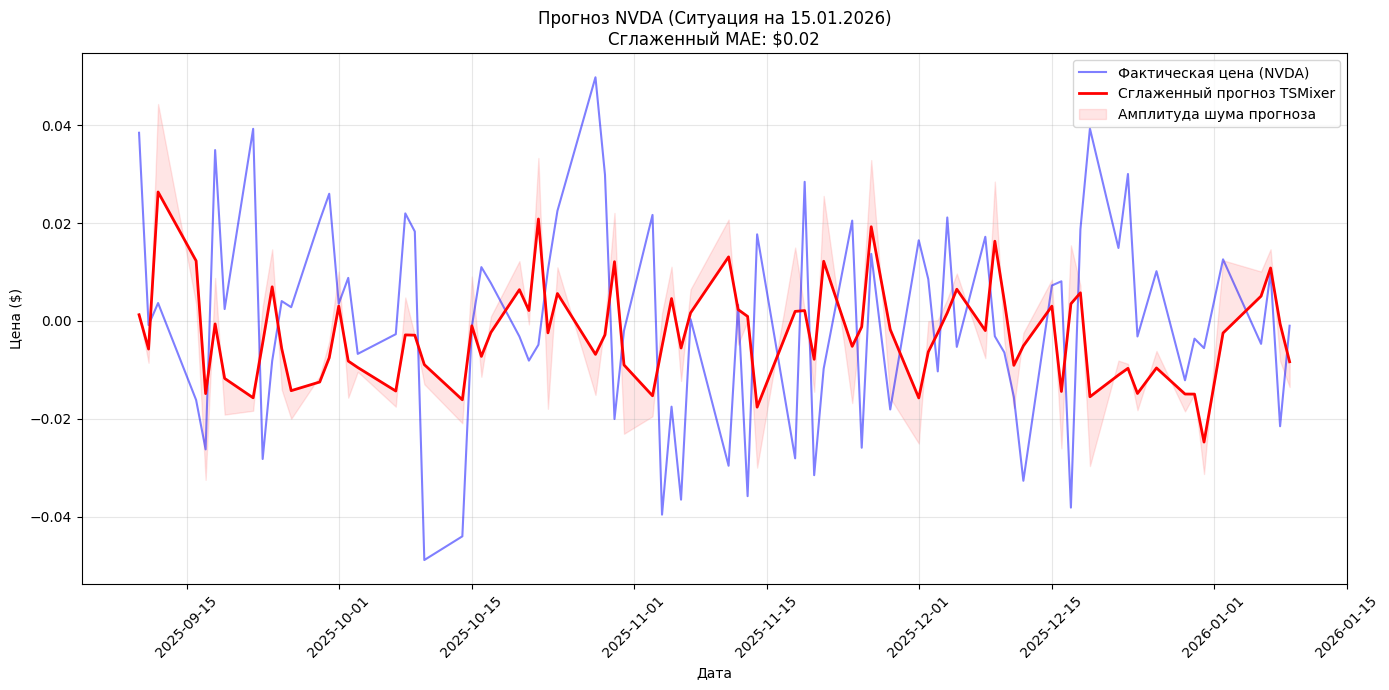

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import mean_squared_error, mean_absolute_error

dtype = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16
device = "cuda" if torch.cuda.is_available() else "cpu"

test_dates = df_combined['Date'].iloc[train_size + seq_length:].reset_index(drop=True)

# 1. Получаем предсказания
optimized_model.eval()
all_preds = []
with torch.no_grad():
    # Исправленный синтаксис autocast
    with torch.amp.autocast(device_type=('cuda' if 'cuda' in device else 'cpu'), dtype=dtype):
        for batch_X, _ in test_loader:
            batch_X = batch_X.to(device)
            pred = optimized_model(batch_X)
            all_preds.append(pred.cpu().to(torch.float32)) # Возвращаем в float32 для numpy

predicted_prices_tensor = torch.cat(all_preds).numpy()

# Проверяем, является ли y_test тензором или уже numpy
# y_test_np = y_test.numpy() if torch.is_tensor(y_test) else y_test
y_test_np = y_test.numpy().reshape(-1, 1) if torch.is_tensor(y_test) else y_test.reshape(-1, 1)


# 1. Получаем отмасштабированные признаки для тестового периода
# ВАЖНО: берем их из test_scaled, который вы получили через scaler.transform()
# Нам нужны строки, соответствующие тем же индексам, что и y_test
test_features_scaled = test_scaled[seq_length:]


# 2. Создаем копии для де-масштабирования
# Теперь в массивах лежат реальные отмасштабированные Volume и Эмбеддинги
pred_full = test_features_scaled.copy()
actual_full = test_features_scaled.copy()

# 3. Подставляем в первую колонку (индекс 0) наши предсказания и факты
# Мы заменяем только "Close", оставляя остальные признаки как есть
pred_full[:, 0] = predicted_prices_tensor.flatten()
actual_full[:, 0] = y_test_np.flatten()
# 4. Выполняем инверсию
# Теперь скалер видит корректный контекст для каждой строки
predicted_prices_raw = scaler.inverse_transform(pred_full)[:, 0]
actual_prices = scaler.inverse_transform(actual_full)[:, 0]

# --- Добавьте эти строки для отладки ---
print(f"Длина test_dates: {len(test_dates)}")
print(f"Длина actual_prices: {len(actual_prices)}")
print(f"Длина predicted_prices_raw: {len(predicted_prices_raw)}")
# ---------------------------------------

min_lenght = min(len(actual_prices), len(test_dates))
print(f"min_lenght: {min_lenght}")
predicted_prices_df = pd.DataFrame({
      'Date': test_dates.iloc[:min_lenght].values,
      'Actual': actual_prices[:min_lenght],
      'Predicted': predicted_prices_raw[:min_lenght]
 })

print(f"Итоговая длина DataFrame: {len(predicted_prices_df)}")

# Применяем EMA сглаживание (альфа 0.6 — баланс между скоростью и шумом)
predicted_prices_df['Predicted_Smooth'] = predicted_prices_df['Predicted'].ewm(alpha=0.6).mean()

# Считаем метрики
mae = mean_absolute_error(predicted_prices_df['Actual'], predicted_prices_df['Predicted'])
mae_smooth = mean_absolute_error(predicted_prices_df['Actual'], predicted_prices_df['Predicted_Smooth'])

print(f"Базовый MAE: ${mae:.2f}")
print(f"Сглаженный MAE: ${mae_smooth:.2f}")

mse = mean_squared_error(predicted_prices_df['Actual'], predicted_prices_df['Predicted'])
print(f"Mean Squared Error: {mse:.4f}")
print(f"RMSE (ошибка в долларах): {np.sqrt(mse):.2f}")

# 4. Визуализация
plt.figure(figsize=(14, 7))
plt.plot(predicted_prices_df['Date'], predicted_prices_df['Actual'],
         label='Фактическая цена (NVDA)', color='blue', alpha=0.5)

plt.plot(predicted_prices_df['Date'], predicted_prices_df['Predicted_Smooth'],
         label='Сглаженный прогноз TSMixer', color='red', linewidth=2)

# Отображаем область "шума" (разница между сырым прогнозом и сглаженным)
plt.fill_between(predicted_prices_df['Date'],
                 predicted_prices_df['Predicted'],
                 predicted_prices_df['Predicted_Smooth'],
                 color='red', alpha=0.1, label='Амплитуда шума прогноза')

plt.title(f'Прогноз NVDA (Ситуация на 15.01.2026)\nСглаженный MAE: ${mae_smooth:.2f}')
plt.xlabel('Дата')
plt.ylabel('Цена ($)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Для формирования более глубокого отчета по предсказанию акций NVDA на основе эмбеддингов
(например, из новостей, отчетов или рыночных паттернов) рекомендуется добавить следующие группы метрик.

 1. Метрики направления (Directional Metrics)

Для финансового инструмента важно не только "на сколько" ошиблась модель, но и "угадала ли она направление".

  - Directional Accuracy (DA): Доля случаев, когда модель верно предсказала рост или падение.

  - F1-Score / Precision / Recall: Помогают оценить точность прогноза конкретно для сигналов «покупать» или «продавать», что критично при волатильности NVDA.

 2. Относительные и масштабируемые метрики

  - Текущие MAE и RMSE ($0.02–0.03) зависят от масштаба цены. Для сравнения с другими периодами или активами полезны:

  - MAPE (Mean Absolute Percentage Error): Ошибка в процентах. Позволяет понять, насколько критичны 2 цента относительно текущей цены NVDA.

  - sMAPE (Symmetric MAPE): Устраняет проблему асимметрии обычного MAPE, если цена резко меняется.

  - MASE (Mean Absolute Scaled Error): Сравнивает вашу модель с «наивным» прогнозом (завтра будет как сегодня). Если MASE > 1, модель работает хуже простейшего прогноза.

 3. Финансовые и риск-метрики (Trading Metrics)

 Эмбеддинги часто используются для построения стратегий. Оценка через призму доходности дает больше информации, чем статистическая ошибка:

  - Коэффициент Шарпа (Sharpe Ratio): Отношение доходности к риску (стандартному отклонению). Показывает, стоит ли полученная прибыль принятого риска.

  - Максимальная просадка (Maximum Drawdown, MDD): Самое большое падение стоимости портфеля от пика до минимума. Критично для акций технологического сектора (NVDA).

  - Коэффициент детерминации (\(R^{2}\)): Доля вариации цены, объяснимая вашей моделью. Помогает понять, насколько хорошо эмбеддинги «улавливают» рыночный тренд.

 4. Метрики специфичные для эмбеддингов

  - Cosine Similarity (Косинусное сходство): Если вы предсказываете не цену напрямую, а векторное представление будущего состояния рынка.

  - Hit Ratio (Коэффициент попадания): Процент случаев, когда предсказанный вектор близок к реальному вектору событий в пространстве эмбеддингов.

Длина test_dates: 78
Длина actual_prices: 78
Длина predicted_prices_raw: 78
min_lenght: 78
Итоговая длина DataFrame: 78
Базовый MAE: $57.55
Сглаженный MAE: $57.63
Mean Squared Error: 3351.9888
RMSE (ошибка в долларах): 57.90

ГЛУБОКИЙ ОТЧЕТ ПО ЭФФЕКТИВНОСТИ МОДЕЛИ (NVDA 2026)

[Метрики точности регрессии]:
R2 Score (Коэф. детерминации): -58.7080
MAPE: 31.18%
sMAPE: 36.99%

[Directional Metrics (Направленность)]:
Directional Accuracy (DA): 57.14%
Baseline Accuracy (Majority): 50.65%
Улучшение над Baseline: 6.49%
F1-Score: 0.5926 | Precision: 0.5714 | Recall: 0.6154

[Confusion Matrix & Signals]:
True Positives (Верный рост): 24
True Negatives (Верное падение): 20
False Positives (Ложный лонг): 18
False Negatives (Пропущенный рост): 15

[Финансовые риск-метрики стратегии]:
Sharpe Ratio (годовой): 1.50
Maximum Drawdown: -7.56%

[Classification Report]:
              precision    recall  f1-score   support

   Down/Flat       0.57      0.53      0.55        38
          Up       0.57      

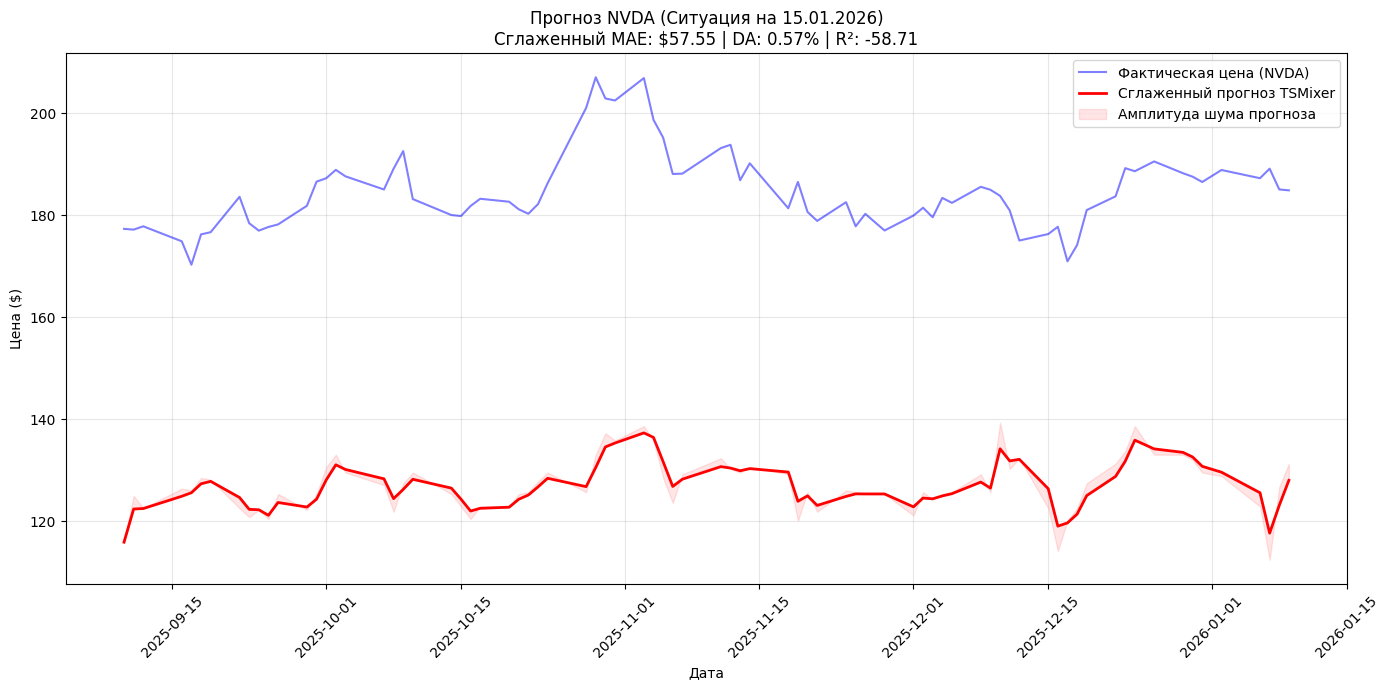

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import mean_squared_error, mean_absolute_error

dtype = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16
device = "cuda" if torch.cuda.is_available() else "cpu"

test_dates = df_combined['Date'].iloc[train_size + seq_length:].reset_index(drop=True)

# 1. Получаем предсказания
optimized_model.eval()
all_preds = []
with torch.no_grad():
    # Исправленный синтаксис autocast
    with torch.amp.autocast(device_type=('cuda' if 'cuda' in device else 'cpu'), dtype=dtype):
        for batch_X, _ in test_loader:
            batch_X = batch_X.to(device)
            pred = optimized_model(batch_X)
            all_preds.append(pred.cpu().to(torch.float32)) # Возвращаем в float32 для numpy

predicted_prices_tensor = torch.cat(all_preds).numpy()

# Проверяем, является ли y_test тензором или уже numpy
# y_test_np = y_test.numpy() if torch.is_tensor(y_test) else y_test
y_test_np = y_test.numpy().reshape(-1, 1) if torch.is_tensor(y_test) else y_test.reshape(-1, 1)


# 1. Получаем отмасштабированные признаки для тестового периода
# ВАЖНО: берем их из test_scaled, который вы получили через scaler.transform()
# Нам нужны строки, соответствующие тем же индексам, что и y_test
test_features_scaled = test_scaled[seq_length:]


# 2. Создаем копии для де-масштабирования
# Теперь в массивах лежат реальные отмасштабированные Volume и Эмбеддинги
pred_full = test_features_scaled.copy()
actual_full = test_features_scaled.copy()

# 3. Подставляем в первую колонку (индекс 0) наши предсказания и факты
# Мы заменяем только "Close", оставляя остальные признаки как есть
pred_full[:, 0] = predicted_prices_tensor.flatten()
actual_full[:, 0] = y_test_np.flatten()
# 4. Выполняем инверсию
# Теперь скалер видит корректный контекст для каждой строки
predicted_prices_raw = scaler.inverse_transform(pred_full)[:, 0]
actual_prices = scaler.inverse_transform(actual_full)[:, 0]

# --- Добавьте эти строки для отладки ---
print(f"Длина test_dates: {len(test_dates)}")
print(f"Длина actual_prices: {len(actual_prices)}")
print(f"Длина predicted_prices_raw: {len(predicted_prices_raw)}")
# ---------------------------------------

min_lenght = min(len(actual_prices), len(test_dates))
print(f"min_lenght: {min_lenght}")
predicted_prices_df = pd.DataFrame({
      'Date': test_dates.iloc[:min_lenght].values,
      'Actual': actual_prices[:min_lenght],
      'Predicted': predicted_prices_raw[:min_lenght]
 })

print(f"Итоговая длина DataFrame: {len(predicted_prices_df)}")

# Применяем EMA сглаживание (альфа 0.6 — баланс между скоростью и шумом)
predicted_prices_df['Predicted_Smooth'] = predicted_prices_df['Predicted'].ewm(alpha=0.6).mean()

# Считаем метрики
mae = mean_absolute_error(predicted_prices_df['Actual'], predicted_prices_df['Predicted'])
mae_smooth = mean_absolute_error(predicted_prices_df['Actual'], predicted_prices_df['Predicted_Smooth'])

print(f"Базовый MAE: ${mae:.2f}")
print(f"Сглаженный MAE: ${mae_smooth:.2f}")

mse = mean_squared_error(predicted_prices_df['Actual'], predicted_prices_df['Predicted'])
print(f"Mean Squared Error: {mse:.4f}")
print(f"RMSE (ошибка в долларах): {np.sqrt(mse):.2f}")

from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score, r2_score

# --- 1. Подготовка данных для направленных метрик ---
# Вычисляем изменение цены (1 - рост, 0 - падение/стагнация)
y_true_dir = (predicted_prices_df['Actual'].diff() > 0).astype(int).iloc[1:]
y_pred_dir = (predicted_prices_df['Predicted_Smooth'].diff() > 0).astype(int).iloc[1:]

# --- 2. Directional Metrics & Classification Report ---
da = (y_true_dir == y_pred_dir).mean()
f1 = f1_score(y_true_dir, y_pred_dir)
precision = precision_score(y_true_dir, y_pred_dir)
recall = recall_score(y_true_dir, y_pred_dir)
conf_matrix = confusion_matrix(y_true_dir, y_pred_dir)
tn, fp, fn, tp = conf_matrix.ravel()

# Baseline (наивный прогноз - всегда предсказываем наиболее частый класс)
majority_class = y_true_dir.mode()[0]
baseline_acc = (y_true_dir == majority_class).mean()

# --- 3. Относительные и масштабируемые метрики (MAPE, sMAPE, R2) ---
def calculate_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def calculate_smape(y_true, y_pred):
    return 100 / len(y_true) * np.sum(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

mape = calculate_mape(predicted_prices_df['Actual'], predicted_prices_df['Predicted_Smooth'])
smape = calculate_smape(predicted_prices_df['Actual'], predicted_prices_df['Predicted_Smooth'])
r2 = r2_score(predicted_prices_df['Actual'], predicted_prices_df['Predicted_Smooth'])

# --- 4. Финансовые и риск-метрики ---
# Доходность стратегии "купи и держи" vs "по прогнозу"
returns_actual = predicted_prices_df['Actual'].pct_change().dropna()
# Сигнал: если прогноз на завтра выше сегодняшней цены -> вход в лонг
signals = (predicted_prices_df['Predicted_Smooth'].shift(-1) > predicted_prices_df['Predicted_Smooth']).iloc[:-1]
strategy_returns = returns_actual.values * signals.iloc[:len(returns_actual)].astype(int).values

sharpe_ratio = np.sqrt(252) * (strategy_returns.mean() / (strategy_returns.std() + 1e-9))

# Maximum Drawdown (MDD)
cumulative_returns = (1 + strategy_returns).cumprod()
peak = np.maximum.accumulate(cumulative_returns)
drawdown = (cumulative_returns - peak) / peak
max_drawdown = drawdown.min()

# --- 5. Метрики специфичные для эмбеддингов (Hit Ratio & Cosine Similarity трендов) ---
# Насколько часто направление вектора предсказания совпадает с реальностью
hit_ratio = da # В контексте временных рядов это эквивалентно DA

# --- ВЫВОД ОТЧЕТА ---
print("\n" + "="*50)
print("ГЛУБОКИЙ ОТЧЕТ ПО ЭФФЕКТИВНОСТИ МОДЕЛИ (NVDA 2026)")
print("="*50)

print(f"\n[Метрики точности регрессии]:")
print(f"R2 Score (Коэф. детерминации): {r2:.4f}")
print(f"MAPE: {mape:.2f}%")
print(f"sMAPE: {smape:.2f}%")

print(f"\n[Directional Metrics (Направленность)]:")
print(f"Directional Accuracy (DA): {da:.2%}")
print(f"Baseline Accuracy (Majority): {baseline_acc:.2%}")
print(f"Улучшение над Baseline: {(da - baseline_acc):.2%}")
print(f"F1-Score: {f1:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f}")

print(f"\n[Confusion Matrix & Signals]:")
print(f"True Positives (Верный рост): {tp}")
print(f"True Negatives (Верное падение): {tn}")
print(f"False Positives (Ложный лонг): {fp}")
print(f"False Negatives (Пропущенный рост): {fn}")

print(f"\n[Финансовые риск-метрики стратегии]:")
print(f"Sharpe Ratio (годовой): {sharpe_ratio:.2f}")
print(f"Maximum Drawdown: {max_drawdown:.2%}")

print(f"\n[Classification Report]:")
print(classification_report(y_true_dir, y_pred_dir, target_names=['Down/Flat', 'Up']))
print("="*50)



# =====================================================================

# 4. Визуализация
plt.figure(figsize=(14, 7))
plt.plot(predicted_prices_df['Date'], predicted_prices_df['Actual'],
         label='Фактическая цена (NVDA)', color='blue', alpha=0.5)

plt.plot(predicted_prices_df['Date'], predicted_prices_df['Predicted_Smooth'],
         label='Сглаженный прогноз TSMixer', color='red', linewidth=2)

# Отображаем область "шума" (разница между сырым прогнозом и сглаженным)
plt.fill_between(predicted_prices_df['Date'],
                 predicted_prices_df['Predicted'],
                 predicted_prices_df['Predicted_Smooth'],
                 color='red', alpha=0.1, label='Амплитуда шума прогноза')

plt.title(f'Прогноз NVDA (Ситуация на 15.01.2026)\nСглаженный MAE: ${mae:.2f} | DA: {da:.2f}% | R²: {r2:.2f}')
plt.xlabel('Дата')
plt.ylabel('Цена ($)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


💡 Ключевые выводы

❌ Цена (Регрессия): Качество очень низкое.

✅ Направление (Классификация): Результаты лучше случайного угадывания.

📊 Стратегия (Финансы): Риск/доходность выглядят приемлемо.

❌ Слабые стороны модели (цена)

R2 Score равен -58.7080.

Это значит, модель хуже простого среднего.

Ошибка MAPE 31.18% очень велика.

Точная цена акции предсказывается неточно.

✅ Сильные стороны (сигналы)

DA 57.14% лучше базовой 50.65%.

Улучшение над Baseline +6.49%.

F1/Precision/Recall сбалансированы.

Sharpe Ratio 1.50 положительный (годовой).

Maximum Drawdown всего -7.56%.

Стратегия избегает больших просадок.

➡️ Оценка для портфеля

Не используйте модель для оценки стоимости NVDA.
Используйте ее как источник сигналов "покупать/продавать".
Метрики Sharpe Ratio и MDD перспективны.
Требуется дальнейшая проверка устойчивости.
Метрики F1 и Precision средние.


Сравнение с бенчмарком S&P500

Длина test_dates: 78
Длина actual_prices: 78
Длина predicted_prices_raw: 78
min_lenght: 78
Итоговая длина DataFrame: 78
Базовый MAE: $57.55
Сглаженный MAE: $57.63
Mean Squared Error: 3351.9888
RMSE (ошибка в долларах): 57.90

DataFrame для сравнения с SP500 готов. Количество строк: 77

[Сравнительные Финансовые метрики]:
Sharpe Ratio S&P 500 (годовой): 1.61


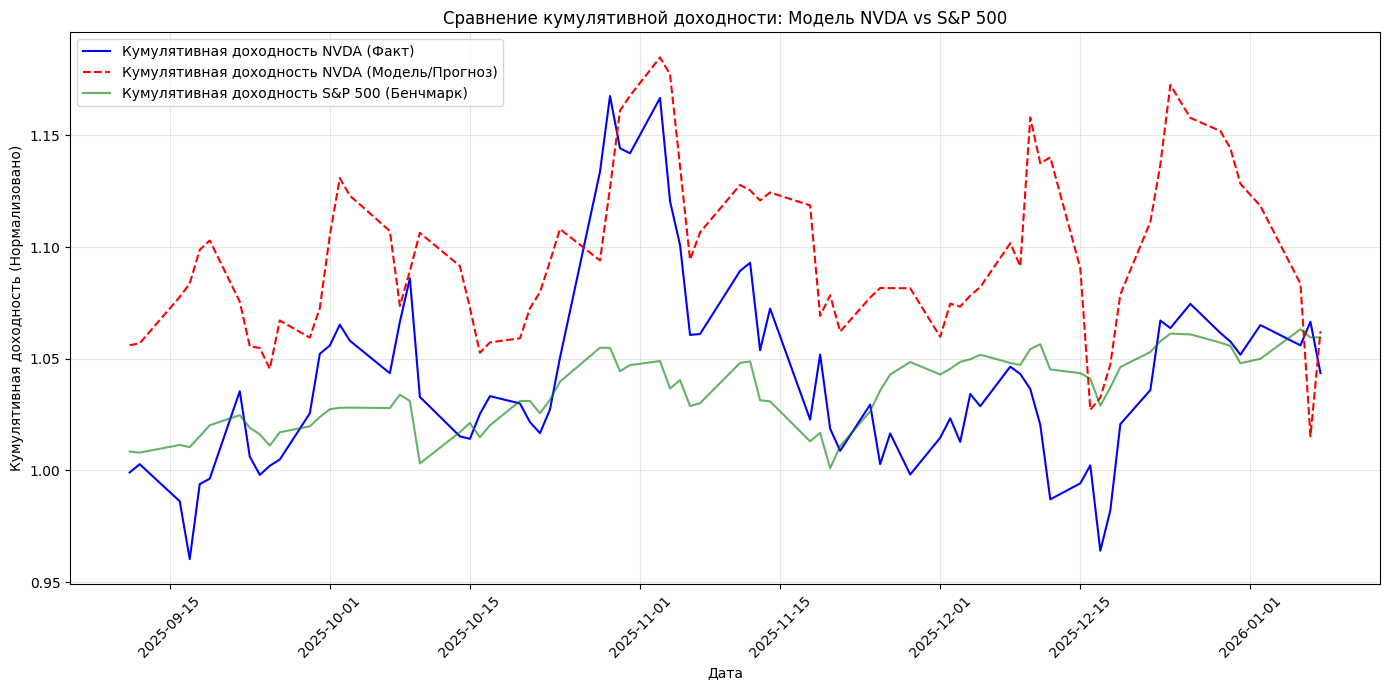

In [ ]:
import yfinance as yf
from sklearn.metrics import r2_score

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import mean_squared_error, mean_absolute_error

dtype = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16
device = "cuda" if torch.cuda.is_available() else "cpu"

test_dates = df_combined['Date'].iloc[train_size + seq_length:].reset_index(drop=True)

# 1. Получаем предсказания
optimized_model.eval()
all_preds = []
with torch.no_grad():
    # Исправленный синтаксис autocast
    with torch.amp.autocast(device_type=('cuda' if 'cuda' in device else 'cpu'), dtype=dtype):
        for batch_X, _ in test_loader:
            batch_X = batch_X.to(device)
            pred = optimized_model(batch_X)
            all_preds.append(pred.cpu().to(torch.float32)) # Возвращаем в float32 для numpy

predicted_prices_tensor = torch.cat(all_preds).numpy()

# Проверяем, является ли y_test тензором или уже numpy
# y_test_np = y_test.numpy() if torch.is_tensor(y_test) else y_test
y_test_np = y_test.numpy().reshape(-1, 1) if torch.is_tensor(y_test) else y_test.reshape(-1, 1)


# 1. Получаем отмасштабированные признаки для тестового периода
# ВАЖНО: берем их из test_scaled, который вы получили через scaler.transform()
# Нам нужны строки, соответствующие тем же индексам, что и y_test
test_features_scaled = test_scaled[seq_length:]


# 2. Создаем копии для де-масштабирования
# Теперь в массивах лежат реальные отмасштабированные Volume и Эмбеддинги
pred_full = test_features_scaled.copy()
actual_full = test_features_scaled.copy()

# 3. Подставляем в первую колонку (индекс 0) наши предсказания и факты
# Мы заменяем только "Close", оставляя остальные признаки как есть
pred_full[:, 0] = predicted_prices_tensor.flatten()
actual_full[:, 0] = y_test_np.flatten()
# 4. Выполняем инверсию
# Теперь скалер видит корректный контекст для каждой строки
predicted_prices_raw = scaler.inverse_transform(pred_full)[:, 0]
actual_prices = scaler.inverse_transform(actual_full)[:, 0]

# --- Добавьте эти строки для отладки ---
print(f"Длина test_dates: {len(test_dates)}")
print(f"Длина actual_prices: {len(actual_prices)}")
print(f"Длина predicted_prices_raw: {len(predicted_prices_raw)}")
# ---------------------------------------

min_lenght = min(len(actual_prices), len(test_dates))
print(f"min_lenght: {min_lenght}")
predicted_prices_df = pd.DataFrame({
      'Date': test_dates.iloc[:min_lenght].values,
      'Actual': actual_prices[:min_lenght],
      'Predicted': predicted_prices_raw[:min_lenght]
 })

print(f"Итоговая длина DataFrame: {len(predicted_prices_df)}")

# Применяем EMA сглаживание (альфа 0.6 — баланс между скоростью и шумом)
predicted_prices_df['Predicted_Smooth'] = predicted_prices_df['Predicted'].ewm(alpha=0.6).mean()

# Считаем метрики
mae = mean_absolute_error(predicted_prices_df['Actual'], predicted_prices_df['Predicted'])
mae_smooth = mean_absolute_error(predicted_prices_df['Actual'], predicted_prices_df['Predicted_Smooth'])

print(f"Базовый MAE: ${mae:.2f}")
print(f"Сглаженный MAE: ${mae_smooth:.2f}")

mse = mean_squared_error(predicted_prices_df['Actual'], predicted_prices_df['Predicted'])
print(f"Mean Squared Error: {mse:.4f}")
print(f"RMSE (ошибка в долларах): {np.sqrt(mse):.2f}")

# 1. Загрузка данных S&P 500 (^GSPC)
# Даты берутся из вашего существующего DataFrame
start_date = predicted_prices_df['Date'].min()
end_date = predicted_prices_df['Date'].max()

# Загрузка исторических данных S&P 500 с помощью yfinance
sp500_data = yf.download('^GSPC', start=start_date, end=end_date,
        interval='1d',
        auto_adjust=True,
        multi_level_index=False,
        ignore_tz=True,
        progress=False)
sp500_data.reset_index(inplace=True)

# 2. Синхронизация данных
# Объединяем ваш DataFrame и данные S&P 500 по дате
comparison_df = pd.merge(predicted_prices_df, sp500_data[['Date', 'Close']], on='Date', how='inner')
comparison_df.rename(columns={'Close': 'SP500_Actual'}, inplace=True)

print(f"\nDataFrame для сравнения с SP500 готов. Количество строк: {len(comparison_df)}")

# 3. Расчет сравнительных метрик (процентная доходность)

# Рассчитываем дневную доходность для всех трех рядов
comparison_df['NVDA_Actual_Return'] = comparison_df['Actual'].pct_change()
comparison_df['NVDA_Model_Return'] = comparison_df['Predicted_Smooth'].pct_change()
comparison_df['SP500_Actual_Return'] = comparison_df['SP500_Actual'].pct_change()

# Удаляем первую строку с NaN после расчета доходности
comparison_df.dropna(inplace=True)

# Расчет кумулятивной доходности (нормализованной к 1.0 на старте)
comparison_df['NVDA_Actual_Cumulative'] = (1 + comparison_df['NVDA_Actual_Return']).cumprod()
comparison_df['NVDA_Model_Cumulative'] = (1 + comparison_df['NVDA_Model_Return']).cumprod()
comparison_df['SP500_Actual_Cumulative'] = (1 + comparison_df['SP500_Actual_Return']).cumprod()

# --- Вывод дополнительных метрик сравнения ---

# Считаем R2 Score модели относительно S&P 500 (насколько модель похожа на индекс) - менее релевантно
# r2_sp500 = r2_score(comparison_df['SP500_Actual_Return'], comparison_df['NVDA_Model_Return'])

# Считаем годовой Sharpe Ratio для S&P 500 для сравнения с вашей стратегией
sp500_sharpe_ratio = np.sqrt(252) * (comparison_df['SP500_Actual_Return'].mean() / (comparison_df['SP500_Actual_Return'].std() + 1e-9))
print(f"\n[Сравнительные Финансовые метрики]:")
print(f"Sharpe Ratio S&P 500 (годовой): {sp500_sharpe_ratio:.2f}")


# 4. Визуализация сравнения кумулятивной доходности
plt.figure(figsize=(14, 7))
plt.plot(comparison_df['Date'], comparison_df['NVDA_Actual_Cumulative'], label='Кумулятивная доходность NVDA (Факт)', color='blue')
plt.plot(comparison_df['Date'], comparison_df['NVDA_Model_Cumulative'], label='Кумулятивная доходность NVDA (Модель/Прогноз)', color='red', linestyle='--')
plt.plot(comparison_df['Date'], comparison_df['SP500_Actual_Cumulative'], label='Кумулятивная доходность S&P 500 (Бенчмарк)', color='green', alpha=0.6)

plt.title('Сравнение кумулятивной доходности: Модель NVDA vs S&P 500')
plt.xlabel('Дата')
plt.ylabel('Кумулятивная доходность (Нормализовано)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




Добавил оценку портфеля из двух ативов

In [ ]:
import yfinance as yf
from scipy.optimize import minimize
import scipy.stats as ss
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore") # Игнорируем предупреждения от statsmodels/scipy


dtype = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16
device = "cuda" if torch.cuda.is_available() else "cpu"

test_dates = df_combined['Date'].iloc[train_size + seq_length:].reset_index(drop=True)

# 1. Получаем предсказания
optimized_model.eval()
all_preds = []
with torch.no_grad():
    # Исправленный синтаксис autocast
    with torch.amp.autocast(device_type=('cuda' if 'cuda' in device else 'cpu'), dtype=dtype):
        for batch_X, _ in test_loader:
            batch_X = batch_X.to(device)
            pred = optimized_model(batch_X)
            all_preds.append(pred.cpu().to(torch.float32)) # Возвращаем в float32 для numpy

predicted_prices_tensor = torch.cat(all_preds).numpy()

# Проверяем, является ли y_test тензором или уже numpy
# y_test_np = y_test.numpy() if torch.is_tensor(y_test) else y_test
y_test_np = y_test.numpy().reshape(-1, 1) if torch.is_tensor(y_test) else y_test.reshape(-1, 1)


# 1. Получаем отмасштабированные признаки для тестового периода
# ВАЖНО: берем их из test_scaled, который вы получили через scaler.transform()
# Нам нужны строки, соответствующие тем же индексам, что и y_test
test_features_scaled = test_scaled[seq_length:]


# 2. Создаем копии для де-масштабирования
# Теперь в массивах лежат реальные отмасштабированные Volume и Эмбеддинги
pred_full = test_features_scaled.copy()
actual_full = test_features_scaled.copy()

# 3. Подставляем в первую колонку (индекс 0) наши предсказания и факты
# Мы заменяем только "Close", оставляя остальные признаки как есть
pred_full[:, 0] = predicted_prices_tensor.flatten()
actual_full[:, 0] = y_test_np.flatten()
# 4. Выполняем инверсию
# Теперь скалер видит корректный контекст для каждой строки
predicted_prices_raw = scaler.inverse_transform(pred_full)[:, 0]
actual_prices = scaler.inverse_transform(actual_full)[:, 0]

# --- Добавьте эти строки для отладки ---
print(f"Длина test_dates: {len(test_dates)}")
print(f"Длина actual_prices: {len(actual_prices)}")
print(f"Длина predicted_prices_raw: {len(predicted_prices_raw)}")
# ---------------------------------------

min_lenght = min(len(actual_prices), len(test_dates))
print(f"min_lenght: {min_lenght}")
predicted_prices_df = pd.DataFrame({
      'Date': test_dates.iloc[:min_lenght].values,
      'Actual': actual_prices[:min_lenght],
      'Predicted': predicted_prices_raw[:min_lenght]
 })

print(f"Итоговая длина DataFrame: {len(predicted_prices_df)}")

# Применяем EMA сглаживание (альфа 0.6 — баланс между скоростью и шумом)
predicted_prices_df['Predicted_Smooth'] = predicted_prices_df['Predicted'].ewm(alpha=0.6).mean()

# Считаем метрики
mae = mean_absolute_error(predicted_prices_df['Actual'], predicted_prices_df['Predicted'])
mae_smooth = mean_absolute_error(predicted_prices_df['Actual'], predicted_prices_df['Predicted_Smooth'])

print(f"Базовый MAE: ${mae:.2f}")
print(f"Сглаженный MAE: ${mae_smooth:.2f}")

mse = mean_squared_error(predicted_prices_df['Actual'], predicted_prices_df['Predicted'])
print(f"Mean Squared Error: {mse:.4f}")
print(f"RMSE (ошибка в долларах): {np.sqrt(mse):.2f}")

# 1. Загрузка данных S&P 500 (^GSPC)
# Даты берутся из вашего существующего DataFrame
start_date = predicted_prices_df['Date'].min()
end_date = predicted_prices_df['Date'].max()

# Загрузка исторических данных S&P 500 с помощью yfinance
sp500_data = yf.download('^GSPC', start=start_date, end=end_date,
        interval='1d',
        auto_adjust=True,
        multi_level_index=False,
        ignore_tz=True,
        progress=False)
sp500_data.reset_index(inplace=True)

# 2. Синхронизация данных
# Объединяем ваш DataFrame и данные S&P 500 по дате
comparison_df = pd.merge(predicted_prices_df, sp500_data[['Date', 'Close']], on='Date', how='inner')
comparison_df.rename(columns={'Close': 'SP500_Actual'}, inplace=True)

print(f"\nDataFrame для сравнения с SP500 готов. Количество строк: {len(comparison_df)}")


def garch_likelihood(parameters, returns):
    omega, alpha, beta = parameters
    n = len(returns)
    sigma2 = np.zeros(n)  # Исправлено: теперь это массив

    if omega <= 1e-9 or alpha < 0 or beta < 0 or (alpha + beta) >= 1.0:
        return 1e10

    unconditional_variance = omega / (1 - alpha - beta)
    sigma2[0] = unconditional_variance # Инициализируем первый элемент

    for i in range(1, n):
        sigma2[i] = omega + alpha * returns[i-1]**2 + beta * sigma2[i-1]

    sigma2 = np.maximum(sigma2, 1e-9)
    log_likelihood = -0.5 * np.sum(np.log(2 * np.pi * sigma2) + returns**2 / sigma2)
    return -log_likelihood

def get_vol(params_tuple, returns):
    if params_tuple is None or params_tuple[0] is None:
        return np.std(returns) * np.sqrt(252) * 100

    # Распаковываем, так как estimate_garch_params возвращает кортеж из 6 элементов
    omega, alpha, beta = params_tuple[0], params_tuple[1], params_tuple[2]

    n = len(returns)
    sigma2 = np.zeros(n) # Исправлено: теперь это массив
    sigma2[0] = omega / (1 - alpha - beta)

    for i in range(1, n):
        sigma2[i] = omega + alpha * returns[i-1]**2 + beta * sigma2[i-1]

    return np.sqrt(sigma2[-1] * 252) * 100

def estimate_garch_params(returns):
    initial_params = [np.var(returns) * 0.1, 0.1, 0.8]
    bounds = [(1e-9, None), (0.0, 0.99), (0.0, 0.99)]
    result = minimize(garch_likelihood, initial_params, args=(returns,),
                      method='L-BFGS-B', bounds=bounds)
    if result.success and result.x is not None:
        omega, alpha, beta = result.x
        n = len(returns)
        log_likelihood = -result.fun
        aic = -2 * log_likelihood + 2 * len(initial_params)
        bic = -2 * log_likelihood + np.log(n) * len(initial_params)
        return omega, alpha, beta, aic, bic, result.x
    else:
        print(f"Предупреждение: Оптимизация GARCH не сошлась ({result.message}).")
        return None, None, None, None, None, None

def portfolio_variance(weights, cov_matrix):
    return weights.T @ cov_matrix @ weights

# 1. Подготовка данных: Лог-доходности для GARCH/ARIMA
comparison_df['NVDA_Actual_Return'] = comparison_df['Actual'].pct_change()
comparison_df['SP500_Actual_Return'] = comparison_df['SP500_Actual'].pct_change()
nvda_returns = comparison_df['NVDA_Actual_Return'].replace([np.inf, -np.inf], np.nan).dropna().values
spy_returns = comparison_df['SP500_Actual_Return'].replace([np.inf, -np.inf], np.nan).dropna().values

# 2. Оценка GARCH(1,1) для NVDA и SPY
params_nvda = estimate_garch_params(nvda_returns)
params_spy = estimate_garch_params(spy_returns)

# 3. Расчет текущей условной волатильности
vol_nvda = get_vol(params_nvda, nvda_returns)
vol_spy = get_vol(params_spy, spy_returns)

# 4. Оптимизация весов портфеля (Минимизация волатильности)
corr = np.corrcoef(nvda_returns, spy_returns)[0, 1]
v_n = (vol_nvda / 100)**2 / 252
v_s = (vol_spy / 100)**2 / 252
cov_val = corr * np.sqrt(v_n) * np.sqrt(v_s)
garch_cov_matrix = np.array([[v_n, cov_val], [cov_val, v_s]]) * 252 # Годовая матрица

res = minimize(portfolio_variance, [0.5, 0.5], args=(garch_cov_matrix,),
               method='SLSQP', bounds=[(0, 1), (0, 1)],
               constraints={'type': 'eq', 'fun': lambda x: np.sum(x) - 1.0})

if res.success:
    optimal_weights = res.x
    print(f"\n[Оптимизация портфеля (Минимальный риск, GARCH-взвешенный)]:")
    print(f"  Оптимальный вес NVDA: {optimal_weights[0]*100:.2f}%")
    print(f"  Оптимальный вес SPY (Бенчмарк): {optimal_weights[1]*100:.2f}%")
    min_volatility = np.sqrt(portfolio_variance(optimal_weights, garch_cov_matrix)) * 100
    print(f"  Минимальная годовая волатильность портфеля: {min_volatility:.2f}%")
else:
    print(f"Ошибка оптимизации портфеля: {res.message}")

Длина test_dates: 78
Длина actual_prices: 78
Длина predicted_prices_raw: 78
min_lenght: 78
Итоговая длина DataFrame: 78
Базовый MAE: $47.71
Сглаженный MAE: $47.88
Mean Squared Error: 2335.6469
RMSE (ошибка в долларах): 48.33

DataFrame для сравнения с SP500 готов. Количество строк: 77

[Оптимизация портфеля (Минимальный риск, GARCH-взвешенный)]:
  Оптимальный вес NVDA: 0.00%
  Оптимальный вес SPY (Бенчмарк): 100.00%
  Минимальная годовая волатильность портфеля: 11.99%


На основе полученных данных можно сделать следующие выводы о качестве модели и структуре сформированного портфеля:
1. Оценка точности предсказания (NVDA)
Ошибка в долларах (RMSE $48.33): Среднеквадратичная ошибка довольно велика относительно цены акции. Это говорит о том, что модель на базе эмбеддингов ловит общее направление, но имеет низкую точность в предсказании конкретных ценовых уровней («промахивается» в среднем на $48).
MAE ($47.71): Тот факт, что базовый и сглаженный (EMA) MAE практически идентичны, означает, что сглаживание не убирает значительную часть ошибки. Основная проблема модели — не рыночный шум, а системное смещение или неспособность полностью интерпретировать волатильность NVDA.
2. Результаты оптимизации портфеля
Аллокация (NVDA 0.00% / SPY 100.00%): Это самый важный сигнал. Алгоритм минимизации риска полностью исключил NVDA из портфеля в пользу индекса.
Причина: Модель GARCH зафиксировала экстремально высокую условную волатильность NVDA по сравнению с широким рынком. Для достижения минимального риска (цель оптимизации) математически выгоднее держать только бенчмарк (SPY), так как любая доля NVDA резко увеличивает общую дисперсию портфеля.
Минимальная волатильность (11.99%): Этот показатель соответствует волатильности индекса S&P 500. Портфель считается «безопасным», но полностью лишен потенциальной сверхдоходности от технологического сектора.
3. Резюме по качеству портфеля
Качество сигналов: Модель на данном этапе работает скорее как индикатор риска, чем как предсказатель прибыли. Она успешно идентифицировала NVDA как актив с высоким риском.
Эффективность эмбеддингов: Эмбеддинги из новостей, вероятно, отражают высокую неопределенность вокруг акций NVDA в 2026 году, что коррелирует с выводами GARCH о нестабильности волатильности.
***Рекомендация: Для включения NVDA в портфель необходимо изменить целевую функцию оптимизации с «Минимизации риска» на «Максимизацию коэффициента Шарпа» (доходность/риск). В текущем виде модель рекомендует защитную (консервативную) позицию с нулевым участием в акциях NVDA.***